<a href="https://colab.research.google.com/github/usamaalmahi/Bangla-Social-Media-Digital-Forensics/blob/main/Bangla_Forensics_FL_UserProfiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangla Social-Media Digital Forensics

**Authors:** Ashif Rabbani, Md. Sakib Muhtadee, Jannatul Ferdous


### Federated Learning, Blockchain Evidence and User-Level Forensic Profiling

This notebook contains the complete pipeline of the project:

* a **text normalisation** front end that recovers words hidden with `*` and converts Romanized Bangla to Bangla script,
* a **BanglaBERT classifier** for five classes of harmful content, trained with **federated learning**,
* a **blockchain ledger** that stores model updates, evidence and user profiles in tamper-evident form, and
* the **digital-forensic (DF) profiling** of public social-media accounts from their activity time series.

---
## 1. Problem statement: DF analysis of social-media user data

The investigator studies a **public Facebook user account**:

```
Facebook  ->  user account (public profile)
                 |
                 |-- About: public personal information (visibility, joined, followers ...)
                 |
                 |-- 1. Monitoring activities
                 |        -> status   (the user writes a post)
                 |        -> share    (the user shares another post)
                 |        -> comment  (the user comments on other posts)
                 |        =  TIME-SERIES DATA (every activity has a date/time)
                 v
             PROFILING with aspects 1..5  ->  profile vector  ->  RESULT: activity profile + risk level
```

The **5 profiling aspects** (Section 8):

| # | Aspect | Question it answers |
|---|--------|---------------------|
| 1 | Activity level | How active is the account and when? |
| 2 | Harmful ratio | What share of the activities is harmful? |
| 3 | Harm type & severity | What kind of harm (offensive, hate, violence, ...) and how serious? |
| 4 | Time trend | Is the harmful behaviour increasing (escalating) over time? |
| 5 | Behaviour channel | Does the user *write* (status), *spread* (share) or *attack others* (comment)? |

The aspects are combined into a **profile vector** and a **risk level** (Low / Medium / High).

---
## 2. Novel contribution: hidden and Romanized harmful comments

On social media, users hide abusive words with `*` and/or write Bangla in Latin letters (Romanized Bangla).
Standard classifiers miss these comments. The proposed pipeline first restores them to standard Bangla, then
classifies them, and stores harmful ones as **tamper-evident evidence** in a blockchain:

```
Example 1 (Romanized + hidden letters)         Example 2 (Bangla + hidden letters)

   kutt*r bacc*                                    কুত্*ার বাচ্চা
        |  Step 1: Unmask (guess hidden letters)        |  Step 1: Unmask
        v                                               v
   kuttar baccha                                   কুত্তার বাচ্চা
        |  Step 2: Transliterate (Latin -> Bangla)
        v                                               |
   কুত্তার বাচ্চা                                         |
        |  Step 3: Classify                             |  Step 3: Classify
        v                                               v
   offensive                                       offensive
        |  Step 4: harmful -> save                      |  Step 4: save
        v                                               v
   BLOCKCHAIN (tamper-evident evidence)            BLOCKCHAIN
```

**Two problems are addressed:**
1. **Class imbalance:** the available data contains far more `normal` comments than harmful ones, so a model is
   biased towards predicting `normal`.
2. **Per-class F1:** the F1 score of **every** class must improve, not only the overall accuracy.

**Approach:** a combined and cleaned dataset with a balanced training core (Section 1), over-sampling of the rare
harmful classes inside every federated client (Section 4), and per-class decision thresholds tuned on the validation
set (Section 6). The test set keeps the natural class distribution, and the improved model is compared with a
baseline class by class.

---
## 3. How the two parts work together

Every activity of a monitored account (Section 8) passes through the novel pipeline
(**unmask → transliterate → classify**) before profiling. Harmful activities become `EVIDENCE` blocks and the final
profile becomes a `USER_PROFILE` block, so the complete investigation record cannot be altered unnoticed.

## 4. Notebook structure

| Section | Content | Part |
|---|---|---|
| 0 | Setup (libraries, configuration) | – |
| 1 | Datasets | – |
| 2 | Text normalisation: clean → unmask → transliterate | Novel |
| 3 | Blockchain (evidence ledger) | Novel |
| 4 | Class imbalance (Problem 1) | Novel |
| 5 | Federated learning classifier | – |
| 6 | Results: per-class F1, baseline vs improved (Problem 2) | Novel |
| 7 | End-to-end analysis of a comment | Novel |
| 8 | DF analysis of user accounts: activities, time series, profiling | Requirement |
| 9 | Blockchain verification, saved outputs, requirement checklist | – |

## 5. Execution

The notebook runs on Google Colab with a GPU (T4). `RUN_MODE` in cell 0.2 selects the configuration:
`FULL` (all training data, 7 federated rounds, BanglaT5 fine-tuning, about 2 hours on a T4) produces the reported
results; `QUICK` (6,000 training comments, 3 rounds, about 15 minutes) is a short functional check.
Data access is described in `README.md`.

<a href="https://colab.research.google.com/github/usamaalmahi/Bangla-Social-Media-Digital-Forensics/blob/main/Bangla_Forensics_FL_UserProfiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Section 0 · Setup

In [1]:
# ============================================================
# 0.1  Install libraries (most are already installed in Colab)
# ============================================================
!pip install -q transformers sentencepiece datasets kagglehub scikit-learn seaborn openpyxl

In [2]:
# ============================================================
# 0.2  Imports and main settings
# ============================================================
import os, re, json, copy, glob, html, random, hashlib, warnings
from io import BytesIO
from collections import Counter, defaultdict
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM
from transformers.utils import logging as hf_logging
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

hf_logging.set_verbosity_error()        # hide long HuggingFace info messages
warnings.filterwarnings("ignore")

# ---------------- Main switches ----------------
RUN_MODE = "FULL"        # @param ["QUICK", "FULL"]
# QUICK = 6,000 training comments, 3 rounds           -> about 15 min on a T4 GPU (functional check)
# FULL  = all training comments, 7 rounds + BanglaT5  -> about 2 hours on a T4 GPU (reported results)

SAVE_TO_DRIVE = True    # @param {type:"boolean"}
# True = save all results in Google Drive, so they are not lost when the Colab session ends

# ---------------- Fixed settings ----------------
SEED = 42               # @param {type:"integer"}
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"               # mixed precision: about 2x faster training on a GPU

# The 5 classes. The position in this list is the class number the model uses.
LABELS   = ["normal", "offensive", "cyberbully", "hate_speech", "violence"]
LABEL2ID = {name: i for i, name in enumerate(LABELS)}
CLASS_COLORS = {"normal": "#4C9F70", "offensive": "#E1B12C", "cyberbully": "#8E44AD",
                "hate_speech": "#E67E22", "violence": "#C0392B"}

CLASSIFIER_MODEL = "csebuetnlp/banglabert"   # Bangla BERT model used by every FL client
T5_MODEL         = "csebuetnlp/banglat5"     # Bangla T5 model used for transliteration
NUM_CLIENTS      = 3                         # number of federated clients (e.g. 3 organisations)
LEARNING_RATE    = 3e-5

# A harmful prediction is saved as blockchain EVIDENCE only when the model is at least
# this sure. Less certain predictions are marked "uncertain" for a human to review.
EVIDENCE_MIN_CONFIDENCE = 0.60

# ---------------- Settings that depend on RUN_MODE ----------------
if RUN_MODE == "QUICK":
    MAX_ROWS       = 6000    # use only a sample of the TRAINING data (class proportions are kept)
    FL_ROUNDS      = 3       # federated rounds
    LOCAL_EPOCHS   = 2       # epochs each client trains per round
    MAX_LEN        = 64      # max tokens per comment
    BATCH_SIZE     = 16
    TRAIN_BANGLAT5 = False   # BanglaT5 training is slow, so it is skipped in QUICK mode
else:
    MAX_ROWS       = None    # use all training rows of the chosen dataset version
    FL_ROUNDS      = 7       # with 5 rounds the validation F1 was still rising at the last round
    LOCAL_EPOCHS   = 1
    MAX_LEN        = 128
    BATCH_SIZE     = 16
    TRAIN_BANGLAT5 = True

# ---------------- Output folder (figures, models, blockchain, profiles) ----------------
OUT_DIR = "outputs"
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_DIR = "/content/drive/MyDrive/bangla_forensics_outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
def save_fig(fig, name):
    """Save a figure as a 300-dpi PNG (print quality, for the report)."""
    path = os.path.join(FIG_DIR, name + ".png")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Figure saved:", path)

print("Run mode :", RUN_MODE)
print("Device   :", DEVICE, "(mixed precision on)" if USE_AMP else "")
print("Outputs  :", OUT_DIR)
if DEVICE == "cpu":
    print("WARNING: no GPU found. Training will be very slow. Use Runtime -> Change runtime type -> T4 GPU.")

Mounted at /content/drive
Run mode : FULL
Device   : cuda (mixed precision on)
Outputs  : /content/drive/MyDrive/bangla_forensics_outputs


---
# Section 1 · Load the datasets

**Forensic dataset (5 classes).** Seven public Bangla datasets are combined into one file by
`dataset/build_dataset.py` (in the project repository). The script maps every source label to our 5 classes with one
written guideline (`dataset/guideline_v1.md`), removes duplicates, drops comments that two sources label differently,
fixes the train / validation / test split, and flags probable label errors in the training part.

| Dataset | Platform | Rows | Main use |
|---|---|---|---|
| **BanHate** | YouTube | 19,203 | all classes |
| **BD-SHS** (train + val + test files) | social media | 50,281 | cyberbully, violence, normal |
| **Bangla Online Comments** (Mendeley, CC BY 4.0) | Facebook | 44,001 | cyberbully, hate_speech |
| **Belal et al. toxic comments** | social media | 16,073 | cyberbully, hate_speech, offensive |
| **BLP-2023 VITD** | YouTube | 6,046 | violence |
| **TB-OLID** (Romanized Bangla, training only) | Facebook | 5,000 | offensive, cyberbully, normal |
| **Bangla vulgar corpus** (drama reviews, training only) | YouTube | 664 | offensive |

TB-OLID and the vulgar corpus give the small `offensive` class more real examples. They are used for
**training only**, so the validation and test sets contain only the five original sources.

Three **dataset versions** can be trained (`DATA_VERSION` in 1.1). Validation and test are the same for all three:

| Version | Training data |
|---|---|
| **A** | BanHate + BD-SHS only (the 2 original sources) |
| **B** | all sources |
| **C** | all sources, probable label errors removed, balanced core: the same number of comments per class (recommended) |

**Data access.** The combined file `data/bangla_forensics_dataset_v1.csv.gz` (about 8 MB) is kept in the
**private** project repository, because two sources have no licence that allows redistribution. Cell 1.1
downloads it with a read-only GitHub token stored as the Colab secret `GITHUB_TOKEN` (the token is never
written into the notebook); the file can also be uploaded to the Colab session directly. Full provenance,
licences and processing steps are documented in `dataset/DATASHEET.md`.

**Other resources:**

| Dataset | Language | Used for |
|---|---|---|
| **BanTH** | Romanized Bangla ↔ Bangla | transliteration (English letters → Bangla) |
| **Nirmol + ToxLex** | Bangla profane words and phrases | unmasking hidden bad words |


In [3]:
# ============================================================
# 1.1  Forensic dataset: 5 public sources, combined and cleaned
# ============================================================
# Built once by dataset/build_dataset.py and stored (compressed) in the PRIVATE GitHub repository.
# Colab reads it with the read-only token saved in Colab Secrets as GITHUB_TOKEN (see README.md).
DATA_VERSION = "C"       # @param ["A", "B", "C"]
EQUAL_REAL_ONLY = False  # @param {type:"boolean"}
# Version C only. False = 6,000 per class; the smaller 'offensive' class is filled up by repeating comments (4.2).
#                True  = every class cut down to the size of the smallest one (3,701), real comments only.
# A = BanHate + BD-SHS only, all training rows      (the 2 original sources)
# B = all sources, all training rows
# C = all sources, probable label errors removed, balanced core (same size per class)   (recommended)

GITHUB_REPO   = "usamaalmahi/Bangla-Social-Media-Digital-Forensics"
GITHUB_BRANCH = "main"
DATASET_PATH  = "data/bangla_forensics_dataset_v1.csv.gz"     # path inside the repository
LOCAL_COPY    = "bangla_forensics_dataset_v1.csv.gz"          # downloaded once per Colab session

def github_token():
    """The read-only GitHub token from Colab Secrets (never type the token itself into the notebook)."""
    try:
        from google.colab import userdata
        return userdata.get("GITHUB_TOKEN")
    except Exception as e:
        print(f"GITHUB_TOKEN secret not available ({type(e).__name__}).")
        return None

def download_from_github(path, dest):
    """Download one file from the private repository through the GitHub API."""
    #token = github_token()
    #if not token:
    #    raise RuntimeError("Add the GITHUB_TOKEN secret (key icon on the left, 'Notebook access' on), or upload "
    #                       f"'{LOCAL_COPY}' to Colab by hand, then run this cell again.")
    response = requests.get(
        f"https://api.github.com/repos/{GITHUB_REPO}/contents/{path}?ref={GITHUB_BRANCH}", timeout=300,
        headers={"Accept": "application/vnd.github.raw+json",
                 "X-GitHub-Api-Version": "2022-11-28"})
    if response.status_code in (401, 403, 404):
        raise RuntimeError(f"GitHub answered {response.status_code} for {path}. Check that the token is valid, has "
                           "'Contents: Read-only' for this repository, and that the file is pushed to "
                           f"the '{GITHUB_BRANCH}' branch.")
    response.raise_for_status()
    with open(dest, "wb") as f:
        f.write(response.content)
    print(f"Downloaded {path} ({len(response.content) / 1e6:.1f} MB)")

if not os.path.isfile(LOCAL_COPY):
    download_from_github(DATASET_PATH, LOCAL_COPY)

full_dataset = pd.read_csv(LOCAL_COPY, encoding="utf-8-sig")    # pandas unpacks the .gz by itself
full_dataset = full_dataset[full_dataset["status"] == "kept"]
in_train = full_dataset["split"] == "train"
if DATA_VERSION == "A":
    in_train &= full_dataset["source"].isin(["banhate", "bdshs"])
elif DATA_VERSION == "C":
    in_train &= full_dataset["train_core"] & ~full_dataset["train_filtered_out"]
if DATA_VERSION == "C" and EQUAL_REAL_ONLY:
    core = full_dataset[in_train]
    smallest = core["label"].value_counts().min()
    keep = core.groupby("label", group_keys=False).apply(lambda g: g.sample(smallest, random_state=SEED)).index
    in_train = full_dataset.index.isin(keep)
    print(f"EQUAL_REAL_ONLY: {smallest} real comments per class, no repeated comments")
    DATA_VERSION = "C_equal"     # saved and compared (6.5, 6.6) as its own version
data = full_dataset[in_train | full_dataset["split"].isin(["val", "test"])]

# QUICK mode: a sample of the training rows (same class proportions); validation and test stay complete
train_part = data[data["split"] == "train"]
if MAX_ROWS and len(train_part) > MAX_ROWS:
    train_part, _ = train_test_split(train_part, train_size=MAX_ROWS, stratify=train_part["label"],
                                     random_state=SEED)
data = pd.concat([train_part, data[data["split"] != "train"]]).reset_index(drop=True)

print(f"Dataset version {DATA_VERSION}: train {(data['split'] == 'train').sum()} | "
      f"validation {(data['split'] == 'val').sum()} | test {(data['split'] == 'test').sum()}")
print(pd.crosstab(data["source"], data["split"]))
data[["text", "source", "label", "split"]].head()


Downloaded data/bangla_forensics_dataset_v1.csv.gz (8.1 MB)
Dataset version C: train 27701 | validation 2000 | test 4000
split    test  train  val
source                   
banhate   586   5488  294
bdshs    1546   7270  773
belal     491   5419  246
boc      1255   4498  626
tbolid      0   2878    0
vitd      122   1618   61
vulgar      0    530    0


,text,source,label,split
0,"এগুলা চিনলে কোন ধোন হবে ভাই,,,ভাল কিছু করেন,,,...",banhate,offensive,train
1,"ইবানের বিছি গেসে,,😂😂",banhate,hate_speech,train
2,মেয়েদের বুদ্ধি যে হাঁটুর নিচে এই ভিডিওটা না দ...,banhate,hate_speech,train
3,ওরা চিনবে শুধু সুগার ড্যাডী,banhate,hate_speech,train
4,বানরের মতো লাগতাছে ইভানাকে,banhate,cyberbully,train


             count  percent
label                      
normal        6000     21.7
offensive     3701     13.4
cyberbully    6000     21.7
hate_speech   6000     21.7
violence      6000     21.7

Imbalance: 'normal' has 1.6x more comments than the smallest class.
Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/1_class_distribution.png


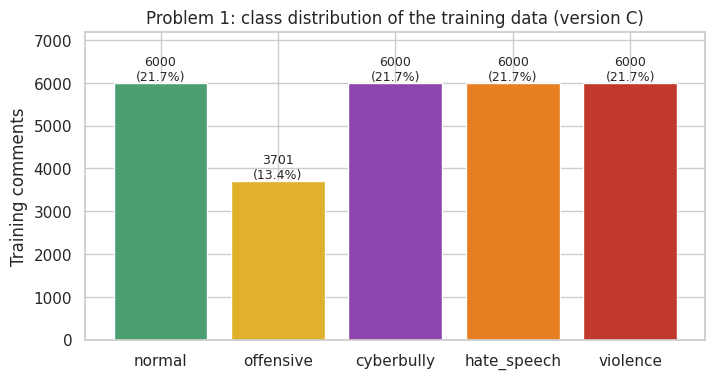

In [4]:
# ============================================================
# 1.2  Class distribution  (this shows Problem 1)
# ============================================================
counts = data.loc[data["split"] == "train", "label"].value_counts().reindex(LABELS, fill_value=0)
print(pd.DataFrame({"count": counts, "percent": (100 * counts / counts.sum()).round(1)}))
print(f"\nImbalance: 'normal' has {counts['normal'] / max(counts.drop('normal').min(), 1):.1f}x "
      f"more comments than the smallest class.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(LABELS, counts.values, color=[CLASS_COLORS[c] for c in LABELS])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}\n({100 * v / counts.sum():.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.2)
ax.set_title(f"Problem 1: class distribution of the training data (version {DATA_VERSION})")
ax.set_ylabel("Training comments")
save_fig(fig, "1_class_distribution")
plt.show()

In [5]:
# ============================================================
# 1.3  Transliteration dataset: BanTH  (Romanized Bangla <-> Bangla)
# ============================================================
def load_banth():
    from datasets import load_dataset
    ds = load_dataset("aplycaebous/BanTH")
    df = pd.concat([ds[split].to_pandas() for split in ds.keys()], ignore_index=True)
    df.columns = [c.lower() for c in df.columns]   # columns used: text (Romanized), bangla
    df = df[["text", "bangla"]].dropna().rename(columns={"text": "roman"})
    return df.astype(str).reset_index(drop=True)

try:
    banth = load_banth()
    print("BanTH:", len(banth), "sentence pairs loaded")
except Exception as e:
    print(f"BanTH download failed ({e}) - using a tiny built-in sample.")
    banth = pd.DataFrame([
        ("Ami tomake bhalobasi", "আমি তোমাকে ভালোবাসি"),
        ("Kemon acho",           "কেমন আছো"),
        ("Valo achi dhonnobad",  "ভালো আছি ধন্যবাদ"),
        ("Tumi kothay",          "তুমি কোথায়"),
        ("Bangla amar bhasha",   "বাংলা আমার ভাষা"),
    ], columns=["roman", "bangla"])

banth.head()

README.md:   0%|          | 0.00/1.82k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/8.23M [00:00<?, ?B/s]

val.csv:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29879 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3736 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3735 [00:00<?, ? examples/s]

BanTH: 37350 sentence pairs loaded


,roman,bangla
0,Dakha mon tah vorah galoh... ❤❤🎉🎉🎉,দেখা মন টা ভোরা গেল...❤❤🎉🎉🎉
1,BGB er moton ei gulare Chakritheke obbahoti de...,বিজিবি এর মত এই গুলারে চক্রকে বাধা দেয়া হোক
2,Or 2 hat kata hok \nAwamiliger ekta kormio je...,অর ২ হাত কাটা হোক আওয়ামী লীগের একটা কাজিও যাত...
3,Janwar ta k dore bichar kora hok🤬🤬,জানাওয়ার টা কে ধরে বিচার করা হোক🤬🤬
4,shorkar er podotag to Pura Bangladesh chai. 18...,সরকার এর পোডোটাগ তো পুরা বাংলাদেশ চাই। ১৮ কোটি...


In [6]:
# ============================================================
# 1.4  Profane word and phrase lists: Nirmol + ToxLex
# ============================================================
# These lists help the unmasker: when a word is hidden with '*', it is most
# likely a bad word, so bad words and bad phrases are preferred as answers.

TOXLEX_URL = ("https://data.mendeley.com/public-files/datasets/9pz8ssmc49/files/"
              "c13b54f5-30d7-4357-8c49-37bc46e510ab/file_downloaded")
TOXLEX_REPO_PATH = "data/ToxLex.xlsx"   # fallback: a copy in the private project repository (Mendeley often blocks Colab)
TOXLEX_FILE = "ToxLex.xlsx"            # local copy; the file can also be uploaded to Colab under this name

def load_nirmol():
    """Nirmol (GitHub): one Bangla slang word or phrase per line."""
    if not os.path.isdir("Nirmol"):
        os.system("git clone -q --depth 1 https://github.com/Sigmakib2/Nirmol.git")
    df = pd.read_csv("Nirmol/datasets/Nirmol-v1-dataset.csv", header=None)   # the file has NO header row
    return df[0].dropna().astype(str).tolist()

def load_toxlex():
    """ToxLex (Mendeley Data): Excel file with 1,959 toxic Bangla bigrams."""
    errors = []
    if not os.path.isfile(TOXLEX_FILE):
        try:
            # A browser-like User-Agent: some servers block the default Python one
            response = requests.get(TOXLEX_URL, timeout=60,
                                    headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"})
            response.raise_for_status()
            if not response.content.startswith(b"PK"):       # every .xlsx file starts with "PK"
                raise ValueError("the server did not send the Excel file (it may block Colab)")
            with open(TOXLEX_FILE, "wb") as f:
                f.write(response.content)
        except Exception as e:
            errors.append(f"Mendeley: {type(e).__name__}: {e}")
    if not os.path.isfile(TOXLEX_FILE):
        try:
            download_from_github(TOXLEX_REPO_PATH, TOXLEX_FILE)   # same read-only token as cell 1.1
        except Exception as e:
            errors.append(f"repository: {type(e).__name__}: {e}")
    if not os.path.isfile(TOXLEX_FILE):
        raise RuntimeError(" | ".join(errors))
    df = pd.read_excel(TOXLEX_FILE)
    column = "Base_bigram" if "Base_bigram" in df.columns else df.columns[0]
    entries = df[column].dropna().astype(str).tolist()
    if not entries:
        raise ValueError("the file has no entries")
    return entries

profane_entries = []
for name, loader in [("Nirmol", load_nirmol), ("ToxLex", load_toxlex)]:
    try:
        entries = loader()
        profane_entries += entries
        print(f"{name}: {len(entries)} entries")
    except Exception as e:
        print(f"{name}: download failed ({type(e).__name__}: {e})")
        if name == "ToxLex":
            print(f"   -> continuing without ToxLex (it can be uploaded to Colab as '{TOXLEX_FILE}')")

# A few common words written in both scripts. They make sure the examples from
# the novel part always work, even when a download fails.
SEED_ROMAN_TO_BANGLA = {
    "kutta": "কুত্তা", "kuttar": "কুত্তার", "bacca": "বাচ্চা", "baccha": "বাচ্চা",
    "shala": "শালা", "gadha": "গাধা", "shuor": "শুয়োর", "shuorer": "শুয়োরের", "harami": "হারামি",
}
print("Profane entries loaded:", len(profane_entries))

Nirmol: 1182 entries
ToxLex: download failed (RuntimeError: Mendeley: HTTPError: 403 Client Error: Forbidden for url: https://data.mendeley.com/public-files/datasets/9pz8ssmc49/files/c13b54f5-30d7-4357-8c49-37bc46e510ab/file_downloaded | repository: RuntimeError: GitHub answered 404 for data/ToxLex.xlsx. Check that the token is valid, has 'Contents: Read-only' for this repository, and that the file is pushed to the 'main' branch.)
   -> continuing without ToxLex (it can be uploaded to Colab as 'ToxLex.xlsx')
Profane entries loaded: 1182


---
# Section 2 · Novel part – text normalisation: clean → unmask → transliterate

**Step 0 – Clean:** remove links, emojis, repeated punctuation and extra spaces.

**Step 1 – Unmask:** a hidden word like `kutt*r` becomes a search pattern `kutt???r`
(each `*` = 1 to 3 unknown letters). We look up all known words that fit the pattern:
* **Phrase first:** the hidden word **and its neighbour** are compared with the bad **phrases** from Nirmol/ToxLex
  (e.g. `কু*ার বা*া` fits the phrase `কুত্তার বাচ্চা`). Using the neighbour gives the right answer more often.
* **Then single words:** a known bad word is preferred, then the most frequent word.
* Words written as `k-u-t-t-a` are simply joined.

This is simple, fast, needs no training and works for **both** Bangla and Romanized text.

**Step 2 – Transliterate:** Romanized words are replaced using a **word dictionary** learned automatically from
BanTH sentence pairs. Different spellings of the same word (`bhalobasi`, `valobashi`, `bhalobashi`) are matched with a
**spelling key**. If a sentence still has unknown words, a fine-tuned **BanglaT5** model translates the whole
sentence (FULL mode only).

In [7]:
# ============================================================
# 2.1  Basic cleaning + small text helpers
# ============================================================
EMOJI_RE = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E0-\U0001F1FF]+")

def clean_text(text):
    """Remove noise that carries no meaning for classification."""
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)                          # &amp; -> &
    text = re.sub(r"http\S+|www\.\S+", " ", text)       # links
    text = EMOJI_RE.sub(" ", text)                      # emojis
    text = text.replace("​", "").replace("﻿", "")   # invisible characters
    text = re.sub(r"[@#](\w+)", r"\1", text)            # @ name / #tag -> name / tag
    text = re.sub(r"([!?।.])\1+", r"\1", text)          # !!! -> !
    return re.sub(r"\s+", " ", text).strip()            # extra spaces

def split_words(text):
    """Split text into lower-case words without punctuation."""
    return re.findall(r"[^\s!?,;:।.\"'()\[\]{}]+", str(text).lower())

def split_punctuation(token):
    """'"kutt*r!' -> ('"', 'kutt*r', '!')  so punctuation does not disturb the lookup."""
    return re.match(r"^([\"'(\[]*)(.*?)([!?,;:।.\"')\]]*)$", token, re.S).groups()

def has_bangla(text): return bool(re.search(r"[ঀ-৿]", text))   # Bangla Unicode block
def has_roman(text):  return bool(re.search(r"[a-zA-Z]", text))

print(clean_text("দারুণ ভিডিও!!! 😂😂 https://fb.com/xyz   #Dhaka"))

দারুণ ভিডিও! Dhaka


In [8]:
# ============================================================
# 2.2  Step 1 - Unmasker (phrase + word pattern matching)
# ============================================================

# Profane entries are split into single BAD WORDS and multi-word BAD PHRASES.
# (Splitting a phrase like 'কুত্তার বাচ্চা' into words would wrongly mark
#  harmless words such as 'ছেলে' (boy) as bad words.)
profane = {" ".join(split_words(clean_text(e))) for e in profane_entries} - {""}
BAD_WORDS   = {p for p in profane if " " not in p}
BAD_WORDS  |= set(SEED_ROMAN_TO_BANGLA) | set(SEED_ROMAN_TO_BANGLA.values())
BAD_PHRASES = {p for p in profane if " " in p}
BAD_PHRASES |= {f"{a} {b}" for a in ["kuttar", "shuorer"] for b in ["bacca", "baccha"]}   # Romanized

# Vocabulary = every word we have seen, with how often we saw it.
VOCAB = Counter()
for text in list(data["text"]) + list(banth["roman"]) + list(banth["bangla"]):
    VOCAB.update(w for w in split_words(clean_text(text)) if "*" not in w)
VOCAB.update(w for p in BAD_WORDS | BAD_PHRASES for w in p.split())   # every bad word is known

# Group words by length so the search is fast
VOCAB_BY_LENGTH = defaultdict(list)
for word in VOCAB:
    VOCAB_BY_LENGTH[len(word)].append(word)


def mask_to_pattern(word):
    """'kutt*r' -> regex 'kutt.{1,3}r' (each group of '*' = 1 to 3 hidden characters)."""
    pieces = re.split(r"\*+", word.lower())
    return ".{1,3}".join(re.escape(p) for p in pieces), "".join(pieces), len(pieces) - 1


def unmask_word(word):
    """Guess the hidden letters of ONE word, e.g. 'kutt*r' -> 'kuttar'."""
    if re.fullmatch(r"(\S[-/])+\S", word):       # k-u-t-t-a  ->  kutta
        return re.sub(r"[-/]", "", word)
    if "*" not in word:
        return word
    pattern, known, stars = mask_to_pattern(word)
    if len(known) < 2:                           # too little information to guess
        return word
    regex = re.compile("^" + pattern + "$")
    candidates = [w for length in range(len(known) + stars, len(known) + 3 * stars + 1)
                  for w in VOCAB_BY_LENGTH.get(length, []) if regex.match(w)]
    if not candidates:
        return word
    # Prefer a known bad word (people usually hide bad words), then the most frequent word
    return max(candidates, key=lambda w: (w in BAD_WORDS, VOCAB[w]))


def unmask_phrase(first, second):
    """Two neighbouring words (at least one hidden) -> the matching bad phrase, or None."""
    parts = [mask_to_pattern(w)[0] if "*" in w else re.escape(w.lower()) for w in (first, second)]
    regex = re.compile("^" + " ".join(parts) + "$")
    candidates = [p for p in BAD_PHRASES if regex.match(p)]
    if not candidates:
        return None
    return max(candidates, key=lambda p: sum(VOCAB[w] for w in p.split())).split()


def unmask_text(text):
    """Unmask a sentence: first try word pairs against bad phrases, then single words."""
    tokens = [split_punctuation(t) for t in text.split()]     # (head, word, tail) for each token
    words = [core for _, core, _ in tokens]
    fixed = {}                                                # position -> unmasked word
    for i in range(len(words) - 1):
        if i not in fixed and ("*" in words[i] or "*" in words[i + 1]):
            match = unmask_phrase(words[i], words[i + 1])
            if match:
                fixed[i], fixed[i + 1] = match
    return " ".join(head + fixed.get(i, unmask_word(core)) + tail
                    for i, (head, core, tail) in enumerate(tokens))


print(f"Vocabulary: {len(VOCAB)} words | bad words: {len(BAD_WORDS)} | bad phrases: {len(BAD_PHRASES)}\n")
for example in ["kutt*r bacc*", "কুত্*ার বাচ্চা", "কু*ার বা*া", "তুই একটা হা*ামি", "k-u-t-t-a"]:
    print(f"{example:20s} ->  {unmask_text(example)}")

Vocabulary: 120457 words | bad words: 737 | bad phrases: 450

kutt*r bacc*         ->  kuttar baccha
কুত্*ার বাচ্চা       ->  কুত্তার বাচ্চা
কু*ার বা*া           ->  কুত্তার বাচ্চা
তুই একটা হা*ামি      ->  তুই একটা হারামি
k-u-t-t-a            ->  kutta


In [9]:
# ============================================================
# 2.3  Step 2 - Transliteration dictionary (learned from BanTH)
# ============================================================
# BanTH gives the same sentence in Romanized and in Bangla script. When both
# versions have the same number of words, word i of one matches word i of the
# other. Counting these matches gives a Roman -> Bangla word dictionary.

pair_counts = defaultdict(Counter)
for roman, bangla in zip(banth["roman"], banth["bangla"]):
    roman_words, bangla_words = split_words(clean_text(roman)), split_words(clean_text(bangla))
    if len(roman_words) == len(bangla_words):
        for r, b in zip(roman_words, bangla_words):
            if has_roman(r) and has_bangla(b):
                pair_counts[r][b] += 1
for r, b in SEED_ROMAN_TO_BANGLA.items():
    pair_counts[r][b] += 1000                      # the seed words always win

ROMAN_TO_BANGLA = {r: c.most_common(1)[0][0] for r, c in pair_counts.items()}

# Spelling key: people write the same Bangla word in many ways (bh/v, sh/s, double letters ...).
# Words with the same key are treated as the same word.
SPELLING_RULES = [("bh", "v"), ("sh", "s"), ("ph", "f"), ("kh", "k"), ("gh", "g"), ("th", "t"),
                  ("dh", "d"), ("ch", "c"), ("jh", "j"), ("z", "j"), ("w", "o"), ("y", "i"),
                  ("ee", "i"), ("oo", "u"), ("aa", "a")]

def spelling_key(word):
    """bhalobasi / valobashi / bhalobashi  ->  'valobasi'"""
    for old, new in SPELLING_RULES:
        word = word.replace(old, new)
    return re.sub(r"(.)\1+", r"\1", word)          # double letters -> single letter

key_counts = defaultdict(Counter)
for r, c in pair_counts.items():
    key_counts[spelling_key(r)].update(c)
KEY_TO_BANGLA = {k: c.most_common(1)[0][0] for k, c in key_counts.items()}

print("Dictionary:", len(ROMAN_TO_BANGLA), "Romanized words |", len(KEY_TO_BANGLA), "spelling keys")

# BanglaT5 is used only when the dictionary does not know a word (set in cell 2.4)
t5_transliterate = None        # set in 2.4 (FULL mode): one sentence at a time, used by the live demo
t5_transliterate_many = None   # set in 2.4 (FULL mode): many sentences in batches, used for the dataset


def transliterate_word(word):
    """One Romanized word -> Bangla, or None if unknown."""
    return ROMAN_TO_BANGLA.get(word) or KEY_TO_BANGLA.get(spelling_key(word))


def transliterate_text(text):
    """Romanized Bangla -> Bangla script. Bangla text is returned unchanged."""
    if not has_roman(text):
        return text
    output, unknown_words = [], 0
    for token in text.split():
        head, core, tail = split_punctuation(token)
        bangla = transliterate_word(core.lower()) if has_roman(core) else None
        if bangla:
            output.append(head + bangla + tail)
        else:
            unknown_words += has_roman(core)
            output.append(token)
    # Some words are still unknown -> BanglaT5 translates the whole (fully Romanized) sentence
    if unknown_words and t5_transliterate is not None and not has_bangla(text):
        return t5_transliterate(text)
    return " ".join(output)

for example in ["kuttar baccha", "Ami tomake bhalobasi", "tui ekta kharap manush"]:
    print(f"{example:25s} ->  {transliterate_text(example)}")

Dictionary: 38589 Romanized words | 29916 spelling keys
kuttar baccha             ->  কুত্তার বাচ্চা
Ami tomake bhalobasi      ->  আমি তোমাকে ভালোবাসি
tui ekta kharap manush    ->  তুই একটা খারাপ মানুষ


In [10]:
# ============================================================
# 2.4  (FULL mode) Fine-tune BanglaT5 for transliteration
# ============================================================
# The dictionary cannot handle words it has never seen. BanglaT5 is a
# sequence-to-sequence model: it reads the Romanized sentence and writes the
# Bangla sentence. It is fine-tuned on BanTH sentence pairs.

T5_DIR        = os.path.join(OUT_DIR, "banglat5_transliterator")
T5_EPOCHS     = 2
T5_TRAIN_ROWS = 20000    # enough pairs for good results; keeps training time reasonable

def train_banglat5(pairs):
    t5_tok = AutoTokenizer.from_pretrained(T5_MODEL, use_fast=False)
    t5 = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL).to(DEVICE)
    optimizer = torch.optim.AdamW(t5.parameters(), lr=3e-4)
    t5.train()
    for epoch in range(T5_EPOCHS):
        pairs = pairs.sample(frac=1, random_state=epoch)       # shuffle every epoch
        total_loss, steps = 0.0, 0
        for i in range(0, len(pairs), 16):
            batch = pairs.iloc[i:i + 16]
            inputs = t5_tok(["transliterate: " + t for t in batch["roman"]], padding=True,
                            truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
            labels = t5_tok(list(batch["bangla"]), padding=True, truncation=True,
                            max_length=64, return_tensors="pt").input_ids
            labels[labels == t5_tok.pad_token_id] = -100       # ignore padding in the loss
            loss = t5(**inputs, labels=labels.to(DEVICE)).loss
            loss.backward()
            optimizer.step(); optimizer.zero_grad()
            total_loss += loss.item(); steps += 1
        print(f"BanglaT5 epoch {epoch + 1}/{T5_EPOCHS}  loss = {total_loss / steps:.4f}")
    t5.save_pretrained(T5_DIR); t5_tok.save_pretrained(T5_DIR)
    return t5, t5_tok

def make_t5_transliterator(t5, t5_tok):
    t5.eval()
    def transliterate(text):
        inputs = t5_tok("transliterate: " + text, return_tensors="pt",
                        truncation=True, max_length=64).to(DEVICE)
        with torch.no_grad():
            output_ids = t5.generate(**inputs, max_new_tokens=64, num_beams=4)
        return t5_tok.decode(output_ids[0], skip_special_tokens=True)
    return transliterate

def make_t5_batch_transliterator(t5, t5_tok, batch_size=32):
    """The same model for many sentences at once (thousands of Romanized comments in the dataset):
    batches, a longer length limit and 2 beams keep this fast without cutting long comments short."""
    t5.eval()
    def transliterate_many(texts):
        outputs = []
        for i in range(0, len(texts), batch_size):
            inputs = t5_tok(["transliterate: " + t for t in texts[i:i + batch_size]], return_tensors="pt",
                            padding=True, truncation=True, max_length=128).to(DEVICE)
            with torch.no_grad():
                output_ids = t5.generate(**inputs, max_new_tokens=128, num_beams=2)
            outputs += t5_tok.batch_decode(output_ids, skip_special_tokens=True)
        return outputs
    return transliterate_many

if TRAIN_BANGLAT5:
    if os.path.isdir(T5_DIR):                                  # already trained in an earlier run
        t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_DIR).to(DEVICE)
        t5_tokenizer = AutoTokenizer.from_pretrained(T5_DIR, use_fast=False)
        print("BanglaT5 loaded from", T5_DIR)
    else:
        pairs = banth.assign(roman=banth["roman"].map(clean_text), bangla=banth["bangla"].map(clean_text))
        pairs = pairs[(pairs["roman"].str.len() > 0) & (pairs["roman"].str.len() < 200)]
        pairs = pairs.sample(min(T5_TRAIN_ROWS, len(pairs)), random_state=SEED)
        t5_model, t5_tokenizer = train_banglat5(pairs)
    t5_transliterate = make_t5_transliterator(t5_model, t5_tokenizer)
    t5_transliterate_many = make_t5_batch_transliterator(t5_model, t5_tokenizer)
    print("BanglaT5 test: 'Ami tomake bhalobasi' ->", t5_transliterate("Ami tomake bhalobasi"))
else:
    print("BanglaT5 skipped (QUICK mode). The dictionary + spelling keys are used for transliteration.")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

BanglaT5 loaded from /content/drive/MyDrive/bangla_forensics_outputs/banglat5_transliterator
BanglaT5 test: 'Ami tomake bhalobasi' -> আমি তো ভালো আছি


In [11]:
# ============================================================
# 2.5  The full normalisation pipeline   (examples from the problem statement)
# ============================================================
def normalize_text(text):
    """clean -> unmask -> transliterate. Returns the final text and every step."""
    steps = {"input": text}
    text = clean_text(text);          steps["cleaned"] = text
    text = unmask_text(text);         steps["unmasked"] = text
    text = transliterate_text(text);  steps["transliterated"] = text
    return text, steps

demo = pd.DataFrame([normalize_text(t)[1] for t in
                     ["kutt*r bacc*", "কুত্*ার বাচ্চা", "Ami tomake bhalobasi", "tui ekta h*rami"]])
display(demo)

# How often do hidden and Romanized comments appear in the real dataset?
n_masked = data["text"].str.contains(r"[^\s*]\*|\*[^\s*]").sum()     # a '*' inside a word
n_roman  = data["text"].map(lambda t: has_roman(t) and not has_bangla(t)).sum()
print(f"Comments with hidden letters (*): {n_masked} | fully Romanized comments: {n_roman}")

def normalize_dataset(texts):
    """normalize_text for the whole dataset. Fully Romanized comments that the dictionary cannot finish
    (e.g. the TB-OLID comments) go to BanglaT5 in batches - one by one would take very long."""
    global t5_transliterate
    saved, t5_transliterate = t5_transliterate, None          # first pass: dictionary + spelling keys only
    try:
        steps = [normalize_text(t)[1] for t in texts]
    finally:
        t5_transliterate = saved
    results = [s["transliterated"] for s in steps]
    todo = [i for i, s in enumerate(steps) if has_roman(s["transliterated"]) and not has_bangla(s["unmasked"])]
    if todo and t5_transliterate_many is not None:
        print(f"BanglaT5: transliterating {len(todo)} Romanized comments in batches ...")
        for i, bangla in zip(todo, t5_transliterate_many([steps[i]["unmasked"] for i in todo])):
            results[i] = bangla
    return results

# Normalise the whole forensic dataset the same way (so training and later use match)
data["clean_text"] = normalize_dataset(list(data["text"]))
data = data[data["clean_text"].str.len() > 0].reset_index(drop=True)
print("Rows after normalisation:", len(data))

,input,cleaned,unmasked,transliterated
0,kutt*r bacc*,kutt*r bacc*,kuttar baccha,কুত্তার বাচ্চা
1,কুত্*ার বাচ্চা,কুত্*ার বাচ্চা,কুত্তার বাচ্চা,কুত্তার বাচ্চা
2,Ami tomake bhalobasi,Ami tomake bhalobasi,Ami tomake bhalobasi,আমি তোমাকে ভালোবাসি
3,tui ekta h*rami,tui ekta h*rami,tui ekta harami,তুই একটা হারামি


Comments with hidden letters (*): 104 | fully Romanized comments: 2877
BanglaT5: transliterating 1714 Romanized comments in batches ...
Rows after normalisation: 33701


---
# Section 3 · Blockchain (tamper-proof evidence ledger)

A blockchain is a list of **blocks**. Each block stores some data **and the hash (fingerprint) of the previous block**.
If anybody changes an old block, its hash changes and the link to the next block breaks, so the change is detected.
A small **proof-of-work** (the hash must start with `00`) makes rewriting the chain costly.

We store four kinds of blocks:

| Block type | Stored when |
|---|---|
| `CLIENT_UPDATE` | a federated client finishes local training (fingerprint of its model weights) |
| `GLOBAL_MODEL` | the server finishes FedAvg (fingerprint + validation scores) |
| `EVIDENCE` | a comment is classified as harmful (with enough confidence) |
| `USER_PROFILE` | a user account profile is created (requirement, Section 8) |

In [12]:
# ============================================================
# 3.1  A simple blockchain
# ============================================================
def sha256(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def model_fingerprint(state_dict):
    """SHA-256 of all model weights. Any change to any weight gives a different value."""
    h = hashlib.sha256()
    for name in sorted(state_dict):
        h.update(name.encode())
        h.update(state_dict[name].detach().cpu().contiguous().numpy().tobytes())
    return h.hexdigest()


class Blockchain:
    DIFFICULTY = 2      # a valid block hash must start with this many zeros

    def __init__(self, file_path):
        self.file_path = file_path
        self.chain = []
        self.add_block("GENESIS", {"message": "Bangla social-media forensic ledger"})

    @staticmethod
    def compute_hash(block):
        content = {k: block[k] for k in ["index", "timestamp", "type", "data", "previous_hash", "nonce"]}
        return sha256(json.dumps(content, sort_keys=True, ensure_ascii=False, default=str))

    def add_block(self, block_type, data):
        block = {
            "index": len(self.chain),
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "type": block_type,
            "data": copy.deepcopy(data),   # a private copy: later changes to `data` cannot alter the block
            "previous_hash": self.chain[-1]["hash"] if self.chain else "0" * 64,
            "nonce": 0,
        }
        # Proof-of-work: change the nonce until the hash starts with "00"
        block["hash"] = self.compute_hash(block)
        while not block["hash"].startswith("0" * self.DIFFICULTY):
            block["nonce"] += 1
            block["hash"] = self.compute_hash(block)
        self.chain.append(block)
        self.save()
        return block

    def verify(self):
        """Re-check every hash and every link. Returns (is_valid, message)."""
        for i, block in enumerate(self.chain):
            if self.compute_hash(block) != block["hash"]:
                return False, f"Block {i} was changed (hash does not match its data)"
            if i > 0 and block["previous_hash"] != self.chain[i - 1]["hash"]:
                return False, f"Block {i} is not linked to block {i - 1}"
        return True, f"All {len(self.chain)} blocks are valid"

    def save(self):
        with open(self.file_path, "w", encoding="utf-8") as f:
            json.dump(self.chain, f, ensure_ascii=False, indent=2, default=str)

    def count_by_type(self):
        return Counter(b["type"] for b in self.chain)


ledger = Blockchain(os.path.join(OUT_DIR, "forensic_blockchain.json"))
print(json.dumps(ledger.chain[0], indent=2))

{
  "index": 0,
  "timestamp": "2026-10-02T16:38:08.442185+00:00",
  "type": "GENESIS",
  "data": {
    "message": "Bangla social-media forensic ledger"
  },
  "previous_hash": "0000000000000000000000000000000000000000000000000000000000000000",
  "nonce": 172,
  "hash": "00d4621fd9f8d64dab43b7ee884af5ea5151e5cc2f2d41e90367e982d6a47b82"
}


---
# Section 4 · Novel part – fixing the class imbalance (Problem 1)

1. **Fixed split (made once in `build_dataset.py`):** 4,000 test and 2,000 validation comments, stratified by source
   and label. They keep the **natural** class mix, are **never** filtered or balanced, and are identical for dataset
   versions A, B and C, so the versions can be compared fairly. The validation set selects the best federated round
   and tunes the thresholds; the test set is used once at the end.
2. **Over-sampling (training set only, inside every client):** every comment is kept, and the comments of the rare
   harmful classes are repeated until each is as large as the largest harmful class (`OVERSAMPLE_TO = 1.0`), but no
   class is repeated more than 3 times over (`MAX_OVERSAMPLE`), so a tiny class is not simply memorised.
   Each client does this with **its own data**, so no comment moves between clients.
   Over-sampling is preferred to under-sampling `normal`: in preliminary runs, under-sampling discarded about
   11,000 real `normal` training comments without improving macro F1.
3. **No class-weighted loss** (`USE_CLASS_WEIGHTS = False`). In preliminary runs, class weights on top of
   re-sampling corrected the imbalance twice: the model labelled too many comments as harmful (recall far above
   precision), `normal` lost F1 and macro F1 did not improve. When enabled, the weights are
   `sqrt(total / (number_of_classes × class_count))`, computed by each federated client from **its own data only**.

In [13]:
# ============================================================
# 4.1  Train / validation / test split (fixed in the dataset file)
# ============================================================
train_df, val_df, test_df = (data[data["split"] == s].reset_index(drop=True) for s in ("train", "val", "test"))
print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")


Train: 27701 | Validation: 2000 | Test: 4000


             before  after
normal         6000   6000
offensive      3701   6000
cyberbully     6000   6000
hate_speech    6000   6000
violence       6000   6000

Imbalance (normal / smallest class): 1.6x -> 1.0x
Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/2_balancing.png


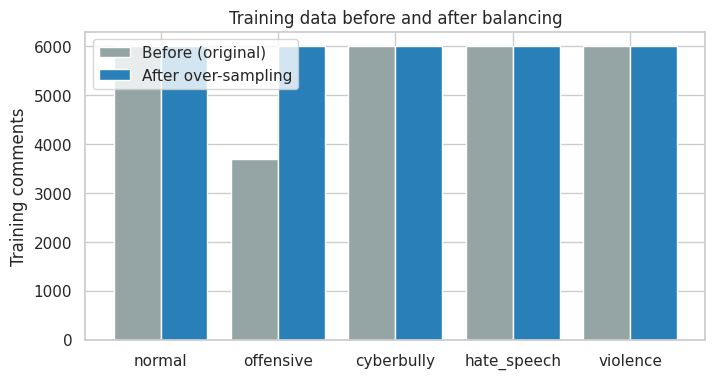

In [14]:
# ============================================================
# 4.2  Over-sampling inside every client (+ optional class weights)
# ============================================================
OVERSAMPLE_TO     = 1.0     # repeat rare harmful classes until they are as big as the biggest harmful class
MAX_OVERSAMPLE    = 3       # ... but never more than 3 x the class's own size
USE_CLASS_WEIGHTS = False   # re-sampling + class weights together corrected the imbalance twice
                            # (too many false 'harmful' predictions), so only over-sampling is used

def split_into_clients(df, n_clients):
    """Give each client its own part of the data. Sorting by label first and then
    dealing rows out like cards gives every client a similar class mix."""
    df = df.sample(frac=1, random_state=SEED).sort_values("label", kind="stable")
    return [df.iloc[i::n_clients].reset_index(drop=True) for i in range(n_clients)]

def balance_training_data(df):
    """Keep EVERY comment and repeat the comments of each rare harmful class until it has
    OVERSAMPLE_TO x (biggest harmful class) comments (at most MAX_OVERSAMPLE x its own size).
    No comment is thrown away."""
    counts = df.loc[df["label"] != "normal", "label"].value_counts()
    target = int(OVERSAMPLE_TO * counts.max())
    parts = [df]
    for label, n in counts.items():
        goal = min(target, MAX_OVERSAMPLE * n)
        if n < goal:
            rows = df[df["label"] == label]
            copies, rest = divmod(goal - n, n)            # whole copies + a random part
            parts += [rows] * copies + [rows.sample(rest, random_state=SEED)]
    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

def class_weights(labels):
    """Rare classes get a bigger weight (square root of the inverse frequency)."""
    counts = np.bincount([LABEL2ID[l] for l in labels], minlength=len(LABELS))
    weights = np.sqrt(len(labels) / (len(LABELS) * np.maximum(counts, 1)))
    return torch.tensor(weights, dtype=torch.float)

# The same clients are used by both runs. Each client balances ITS OWN data (the data never leaves the client).
baseline_clients  = split_into_clients(train_df, NUM_CLIENTS)
balanced_clients  = [balance_training_data(c) for c in baseline_clients]
balanced_train_df = pd.concat(balanced_clients, ignore_index=True)   # all clients together, for the table

# Compare before / after
before = train_df["label"].value_counts().reindex(LABELS, fill_value=0)
after  = balanced_train_df["label"].value_counts().reindex(LABELS, fill_value=0)
balance_table = pd.DataFrame({"before": before, "after": after}, index=LABELS)
if USE_CLASS_WEIGHTS:
    balance_table["class_weight"] = class_weights(balanced_train_df["label"]).numpy().round(2)
print(balance_table)
def imbalance(counts):
    """How many times more 'normal' comments than the smallest harmful class."""
    return counts["normal"] / max(counts.drop("normal").min(), 1)

print(f"\nImbalance (normal / smallest class): {imbalance(before):.1f}x -> {imbalance(after):.1f}x")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(LABELS))
ax.bar(x - 0.2, before.values, width=0.4, label="Before (original)", color="#95A5A6")
ax.bar(x + 0.2, after.values,  width=0.4, label="After over-sampling", color="#2980B9")
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_ylabel("Training comments"); ax.set_title("Training data before and after balancing")
ax.legend()
save_fig(fig, "2_balancing")
plt.show()

---
# Section 5 · Federated learning classifier

**Idea:** several organisations (clients) want to train one model together **without sharing their private data**.

In every **round**:
1. The server sends the current **global model** to every client.
2. Each client trains it on **its own data** for a few epochs.
3. Each client sends back only its **model weights** (never the data). A fingerprint is stored in the blockchain.
4. The server averages the weights (**FedAvg**, bigger clients count more) → new global model, also stored in the blockchain.

After the last round, the global model of the round with the **best validation macro F1** is kept.
All clients use the same model (**BanglaBERT** + a classification layer), so the averaging is meaningful.

In [15]:
# ============================================================
# 5.1  Helpers: data loaders, local training, FedAvg, prediction
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(CLASSIFIER_MODEL)

def make_loader(df, shuffle):
    """Convert comments + labels into batches of token ids."""
    enc = tokenizer(list(df["clean_text"]), truncation=True, padding="max_length",
                    max_length=MAX_LEN, return_tensors="pt")
    labels = torch.tensor([LABEL2ID[l] for l in df["label"]])
    return DataLoader(TensorDataset(enc["input_ids"], enc["attention_mask"], labels),
                      batch_size=BATCH_SIZE, shuffle=shuffle)

def new_model():
    return AutoModelForSequenceClassification.from_pretrained(
        CLASSIFIER_MODEL, num_labels=len(LABELS),
        id2label=dict(enumerate(LABELS)), label2id=LABEL2ID).to(DEVICE)

def train_local(model, loader, weights=None):
    """One client trains the model on its own data. Returns the average loss."""
    loss_fn = torch.nn.CrossEntropyLoss(weight=None if weights is None else weights.to(DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)      # needed for mixed precision
    model.train()
    total_loss, steps = 0.0, 0
    for epoch in range(LOCAL_EPOCHS):
        for input_ids, mask, labels in loader:
            input_ids, mask, labels = input_ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
            with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=USE_AMP):
                logits = model(input_ids=input_ids, attention_mask=mask).logits
            loss = loss_fn(logits.float(), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # avoid too-large updates
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            total_loss += loss.item(); steps += 1
    return total_loss / max(steps, 1)

def fed_avg(client_states, client_sizes):
    """FedAvg: new weight = sum(client weight x client_size / total_size)."""
    total = sum(client_sizes)
    averaged = {}
    for name, first in client_states[0].items():
        if first.is_floating_point():
            averaged[name] = sum(state[name] * (size / total)
                                 for state, size in zip(client_states, client_sizes))
        else:
            averaged[name] = first      # integer buffers (e.g. position ids) are not averaged
    return averaged

@torch.no_grad()
def predict_proba(model, texts, batch_size=64):
    """Return class probabilities for a list of (already normalised) texts."""
    model.eval()
    all_probs = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(list(texts[i:i + batch_size]), truncation=True, padding=True,
                        max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=USE_AMP):
            logits = model(**enc).logits
        all_probs.append(torch.softmax(logits.float(), dim=-1).cpu())
    return torch.cat(all_probs).numpy()

def adjust_probs(probs, bias=None):
    """Move the decision threshold of every class: add a per-class bias to the log-probabilities
    and renormalise. bias = None leaves the probabilities unchanged (see 6.2)."""
    if bias is None:
        return probs
    scores = np.log(np.clip(probs, 1e-9, 1.0)) + bias
    scores = np.exp(scores - scores.max(axis=1, keepdims=True))
    return scores / scores.sum(axis=1, keepdims=True)

def evaluate(model, df, bias=None):
    """Accuracy, macro F1 and F1 of every class on a labelled DataFrame."""
    y_true = [LABEL2ID[l] for l in df["label"]]
    y_pred = adjust_probs(predict_proba(model, list(df["clean_text"])), bias).argmax(axis=1)
    per_class = f1_score(y_true, y_pred, labels=range(len(LABELS)), average=None, zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=range(len(LABELS)), average="macro", zero_division=0),
        "per_class_f1": dict(zip(LABELS, per_class.round(4))),
        "y_true": y_true, "y_pred": y_pred,
    }

print("Helpers ready.")

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/528k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Helpers ready.


In [16]:
# ============================================================
# 5.2  The federated training loop
# ============================================================
def run_federated(clients, use_class_weights, run_name):
    """Train one global model with FedAvg on the clients' own datasets (see 4.2).
    Every step is recorded in the blockchain.
    Returns the global model of the round with the best validation macro F1."""
    print(f"\n========== Federated training: {run_name} ==========")
    loaders = [make_loader(c, shuffle=True) for c in clients]
    for i, c in enumerate(clients, 1):
        print(f"Client {i}: {len(c)} comments  {c['label'].value_counts().to_dict()}")

    global_model = new_model()
    history, best = [], {"macro_f1": -1.0, "round": 0, "state": None}
    for rnd in range(1, FL_ROUNDS + 1):
        states, sizes = [], []
        for cid, (client_df, loader) in enumerate(zip(clients, loaders), 1):
            local_model = copy.deepcopy(global_model)          # 1. client receives the global model
            weights = class_weights(client_df["label"]) if use_class_weights else None
            loss = train_local(local_model, loader, weights)   # 2. trains on its own data
            state = {k: v.detach().cpu().clone() for k, v in local_model.state_dict().items()}
            states.append(state); sizes.append(len(client_df)) # 3. sends back only the weights
            ledger.add_block("CLIENT_UPDATE", {
                "run": run_name, "round": rnd, "client": cid, "samples": len(client_df),
                "train_loss": round(loss, 4), "weights_hash": model_fingerprint(state)})
            print(f"  Round {rnd} | client {cid} | loss = {loss:.4f}")
            del local_model
            if DEVICE == "cuda":
                torch.cuda.empty_cache()

        global_model.load_state_dict(fed_avg(states, sizes))  # 4. server averages (FedAvg)
        del states

        result = evaluate(global_model, val_df)                # validation set picks the best round
        ledger.add_block("GLOBAL_MODEL", {
            "run": run_name, "round": rnd, "val_accuracy": round(float(result["accuracy"]), 4),
            "val_macro_f1": round(float(result["macro_f1"]), 4),
            "weights_hash": model_fingerprint(global_model.state_dict())})
        history.append({"round": rnd, "accuracy": result["accuracy"],
                        "macro_f1": result["macro_f1"], **result["per_class_f1"]})
        print(f"Round {rnd} done | validation accuracy = {result['accuracy']:.4f} "
              f"| validation macro F1 = {result['macro_f1']:.4f}")
        if result["macro_f1"] > best["macro_f1"]:
            best = {"macro_f1": result["macro_f1"], "round": rnd,
                    "state": {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}}

    global_model.load_state_dict(best["state"])
    print(f"-> Using the model of round {best['round']} (best validation macro F1 = {best['macro_f1']:.4f})")
    return global_model, pd.DataFrame(history)

---
# Section 6 · Novel part – results: per-class F1 (Problem 2)

Two models are trained with exactly the same federated setup:

| Run | Training data | Loss | Decision |
|---|---|---|---|
| **Baseline** | original (imbalanced) | standard cross-entropy | class with the highest probability |
| **Improved** | over-sampled rare harmful classes | standard cross-entropy | per-class thresholds tuned on the validation set |

**Threshold tuning (6.2):** a model trained on imbalanced data assigns too much probability to `normal`. Every class
receives a small bias that shifts its decision threshold. The biases are chosen on the **validation set** to maximise
macro F1; the test set is never used for this, so the test scores remain unbiased.

Both models are evaluated on the **same untouched test set**. Table 6.3 also reports the improved model *before*
threshold tuning (`oversampled_F1`), so the contribution of each step is visible.

**Dataset versions and seeds (6.5, 6.6):** every run stores its scores in `runs/` in the output folder. Dataset
versions A, B and C are each trained with seeds 42, 43 and 44, and cell 6.6 reports the mean ± standard deviation per
version. A difference between versions is treated as meaningful only when it clearly exceeds the spread between seeds.
Cell 6.5 also reports the scores per source and on the **checked test labels**: all 4,000 test comments re-labelled
blind against the label guideline (single LLM annotator; see `dataset/DATASHEET.md`).

**Metric:** macro F1 (the unweighted mean F1 over the five classes) is the main metric, because accuracy is dominated
by the `normal` class. Identical runs differ by about 0.002–0.005 macro F1 (GPU non-determinism), so smaller
differences are not interpreted as improvements. The confusion matrices in 6.4 show which classes are confused.

In [17]:
# ============================================================
# 6.1  Train the baseline and the improved model
# ============================================================
RUN_BASELINE = True     # False = train only the improved model (e.g. for the extra seeds in 6.6)

if RUN_BASELINE:
    baseline_model, baseline_history = run_federated(baseline_clients, use_class_weights=False, run_name="baseline")
    baseline_result = evaluate(baseline_model, test_df)
    del baseline_model                         # free GPU memory before the next run
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

model, improved_history = run_federated(balanced_clients, use_class_weights=USE_CLASS_WEIGHTS, run_name="improved")
oversampled_result = evaluate(model, test_df)     # before threshold tuning (6.2)


========== Federated training: baseline ==========
Client 1: 9234 comments  {'cyberbully': 2000, 'hate_speech': 2000, 'normal': 2000, 'violence': 2000, 'offensive': 1234}
Client 2: 9234 comments  {'cyberbully': 2000, 'hate_speech': 2000, 'normal': 2000, 'violence': 2000, 'offensive': 1234}
Client 3: 9233 comments  {'cyberbully': 2000, 'hate_speech': 2000, 'normal': 2000, 'violence': 2000, 'offensive': 1233}


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

model.safetensors: downloading bytes:           |  0.00B            

  Round 1 | client 1 | loss = 1.0494
  Round 1 | client 2 | loss = 1.0978
  Round 1 | client 3 | loss = 1.0580
Round 1 done | validation accuracy = 0.7130 | validation macro F1 = 0.5798
  Round 2 | client 1 | loss = 0.7876
  Round 2 | client 2 | loss = 0.8081
  Round 2 | client 3 | loss = 0.7817
Round 2 done | validation accuracy = 0.6950 | validation macro F1 = 0.6097
  Round 3 | client 1 | loss = 0.6700
  Round 3 | client 2 | loss = 0.6812
  Round 3 | client 3 | loss = 0.6558
Round 3 done | validation accuracy = 0.7110 | validation macro F1 = 0.6225
  Round 4 | client 1 | loss = 0.5639
  Round 4 | client 2 | loss = 0.5798
  Round 4 | client 3 | loss = 0.5549
Round 4 done | validation accuracy = 0.6995 | validation macro F1 = 0.6167
  Round 5 | client 1 | loss = 0.4733
  Round 5 | client 2 | loss = 0.5006
  Round 5 | client 3 | loss = 0.4715
Round 5 done | validation accuracy = 0.7040 | validation macro F1 = 0.6112
  Round 6 | client 1 | loss = 0.3893
  Round 6 | client 2 | loss = 0.4

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

  Round 1 | client 1 | loss = 1.0574
  Round 1 | client 2 | loss = 1.0738
  Round 1 | client 3 | loss = 1.0495
Round 1 done | validation accuracy = 0.6880 | validation macro F1 = 0.5979
  Round 2 | client 1 | loss = 0.7623
  Round 2 | client 2 | loss = 0.7719
  Round 2 | client 3 | loss = 0.7542
Round 2 done | validation accuracy = 0.6960 | validation macro F1 = 0.6137
  Round 3 | client 1 | loss = 0.6421
  Round 3 | client 2 | loss = 0.6350
  Round 3 | client 3 | loss = 0.6201
Round 3 done | validation accuracy = 0.6970 | validation macro F1 = 0.6090
  Round 4 | client 1 | loss = 0.5206
  Round 4 | client 2 | loss = 0.5267
  Round 4 | client 3 | loss = 0.5070
Round 4 done | validation accuracy = 0.6945 | validation macro F1 = 0.6120
  Round 5 | client 1 | loss = 0.4258
  Round 5 | client 2 | loss = 0.4170
  Round 5 | client 3 | loss = 0.4023
Round 5 done | validation accuracy = 0.7270 | validation macro F1 = 0.6497
  Round 6 | client 1 | loss = 0.3531
  Round 6 | client 2 | loss = 0.3

In [18]:
# ============================================================
# 6.2  Tune the decision thresholds on the VALIDATION set
# ============================================================
def tune_class_bias(probs, y_true, grid=np.linspace(-2, 2, 41), passes=3):
    """Find one bias per class that gives the highest macro F1.
    Coordinate search: try every grid value for one class at a time, keep the best, repeat."""
    def macro_f1(bias):
        y_pred = adjust_probs(probs, bias).argmax(axis=1)
        return f1_score(y_true, y_pred, labels=range(len(LABELS)), average="macro", zero_division=0)
    bias = np.zeros(len(LABELS))
    best = macro_f1(bias)
    for _ in range(passes):
        for k in range(1, len(LABELS)):          # 'normal' stays at 0: only the differences matter
            for value in grid:
                trial = bias.copy(); trial[k] = value
                score = macro_f1(trial)
                if score > best:
                    best, bias = score, trial
    return bias, best

val_probs = predict_proba(model, list(val_df["clean_text"]))
val_true  = [LABEL2ID[l] for l in val_df["label"]]
untuned_val_f1 = f1_score(val_true, val_probs.argmax(axis=1), labels=range(len(LABELS)),
                          average="macro", zero_division=0)
CLASS_BIAS, tuned_val_f1 = tune_class_bias(val_probs, val_true)

print("Bias per class (log scale, > 0 = predicted more often):")
print(pd.Series(CLASS_BIAS.round(2), index=LABELS).to_string())
print(f"\nValidation macro F1: {untuned_val_f1:.4f} -> {tuned_val_f1:.4f}")

improved_result = evaluate(model, test_df, bias=CLASS_BIAS)   # the final model, used from here on

# Save the final classifier together with its class biases
final_dir = os.path.join(OUT_DIR, "final_classifier")
model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
with open(os.path.join(final_dir, "class_bias.json"), "w") as f:
    json.dump(dict(zip(LABELS, CLASS_BIAS.round(4).tolist())), f, indent=2)
print("\nFinal classifier + class biases saved to", final_dir)

Bias per class (log scale, > 0 = predicted more often):
normal         0.0
offensive     -1.4
cyberbully    -0.3
hate_speech   -2.0
violence      -2.0

Validation macro F1: 0.6509 -> 0.6700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final classifier + class biases saved to /content/drive/MyDrive/bangla_forensics_outputs/final_classifier


,baseline_F1,oversampled_F1,improved_F1,change
normal,0.8031,0.7879,0.7942,-0.0089
offensive,0.3432,0.3500,0.3740,0.0308
cyberbully,0.6638,0.6760,0.6878,0.0240
hate_speech,0.6496,0.6594,0.6930,0.0434
violence,0.6795,0.6832,0.6966,0.0171
MACRO F1,0.6278,0.6313,0.6491,0.0213
ACCURACY,0.7105,0.7093,0.7235,0.0130


oversampled = over-sampling only | improved = over-sampling + tuned thresholds (final model)
F1 improved for 4 of 5 classes: ['offensive', 'cyberbully', 'hate_speech', 'violence']
Macro F1: baseline 0.6278 -> over-sampling 0.6313 -> + thresholds 0.6491
(Accuracy can go down a little when the rare harmful classes are predicted more often.)

Detailed report (improved model, test set):
              precision    recall  f1-score   support

      normal       0.90      0.71      0.79      1864
   offensive       0.29      0.52      0.37        94
  cyberbully       0.64      0.74      0.69      1206
 hate_speech       0.67      0.72      0.69       477
    violence       0.62      0.80      0.70       359

    accuracy                           0.72      4000
   macro avg       0.62      0.70      0.65      4000
weighted avg       0.76      0.72      0.73      4000

Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/3_per_class_f1.png


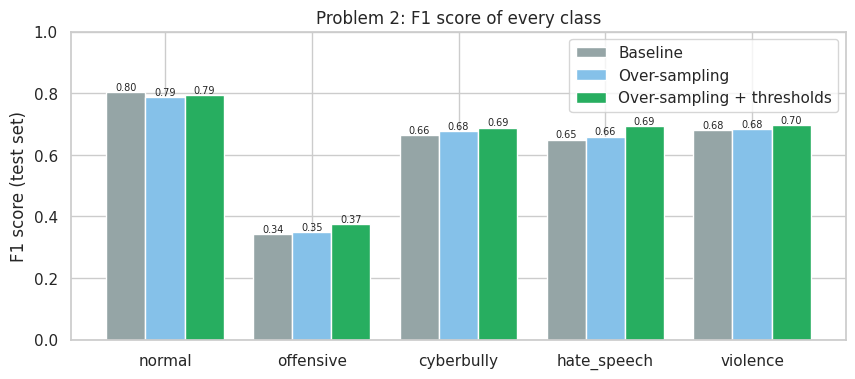

In [19]:
# ============================================================
# 6.3  Per-class F1 table and chart (baseline vs improved, TEST set)
# ============================================================
columns = {"oversampled_F1": oversampled_result, "improved_F1": improved_result}
if RUN_BASELINE:
    columns = {"baseline_F1": baseline_result, **columns}
table = pd.DataFrame({name: r["per_class_f1"] for name, r in columns.items()}).reindex(LABELS)
table.loc["MACRO F1"] = [round(r["macro_f1"], 4) for r in columns.values()]
table.loc["ACCURACY"] = [round(r["accuracy"], 4) for r in columns.values()]
if RUN_BASELINE:
    table["change"] = (table["improved_F1"] - table["baseline_F1"]).round(4)
table.to_csv(os.path.join(OUT_DIR, "per_class_f1.csv"))
display(table)
print("oversampled = over-sampling only | improved = over-sampling + tuned thresholds (final model)")

if RUN_BASELINE:
    better = [l for l in LABELS if table.loc[l, "change"] > 0]
    print(f"F1 improved for {len(better)} of {len(LABELS)} classes: {better}")
    print(f"Macro F1: baseline {baseline_result['macro_f1']:.4f} -> over-sampling {oversampled_result['macro_f1']:.4f} "
          f"-> + thresholds {improved_result['macro_f1']:.4f}")
    print("(Accuracy can go down a little when the rare harmful classes are predicted more often.)")

print("\nDetailed report (improved model, test set):")
print(classification_report(improved_result["y_true"], improved_result["y_pred"],
                            labels=range(len(LABELS)), target_names=LABELS, zero_division=0))

names  = {"baseline_F1": "Baseline", "oversampled_F1": "Over-sampling",
          "improved_F1": "Over-sampling + thresholds"}
colors = {"baseline_F1": "#95A5A6", "oversampled_F1": "#85C1E9", "improved_F1": "#27AE60"}
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(LABELS))
width = 0.8 / len(columns)
for j, (name, r) in enumerate(columns.items()):
    bars = ax.bar(x + (j - (len(columns) - 1) / 2) * width, [r["per_class_f1"][l] for l in LABELS], width,
                  label=names[name], color=colors[name])
    ax.bar_label(bars, fmt="%.2f", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(LABELS); ax.set_ylim(0, 1)
ax.set_ylabel("F1 score (test set)"); ax.set_title("Problem 2: F1 score of every class")
ax.legend()
save_fig(fig, "3_per_class_f1")
plt.show()

Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/4_rounds_and_confusion_matrix.png


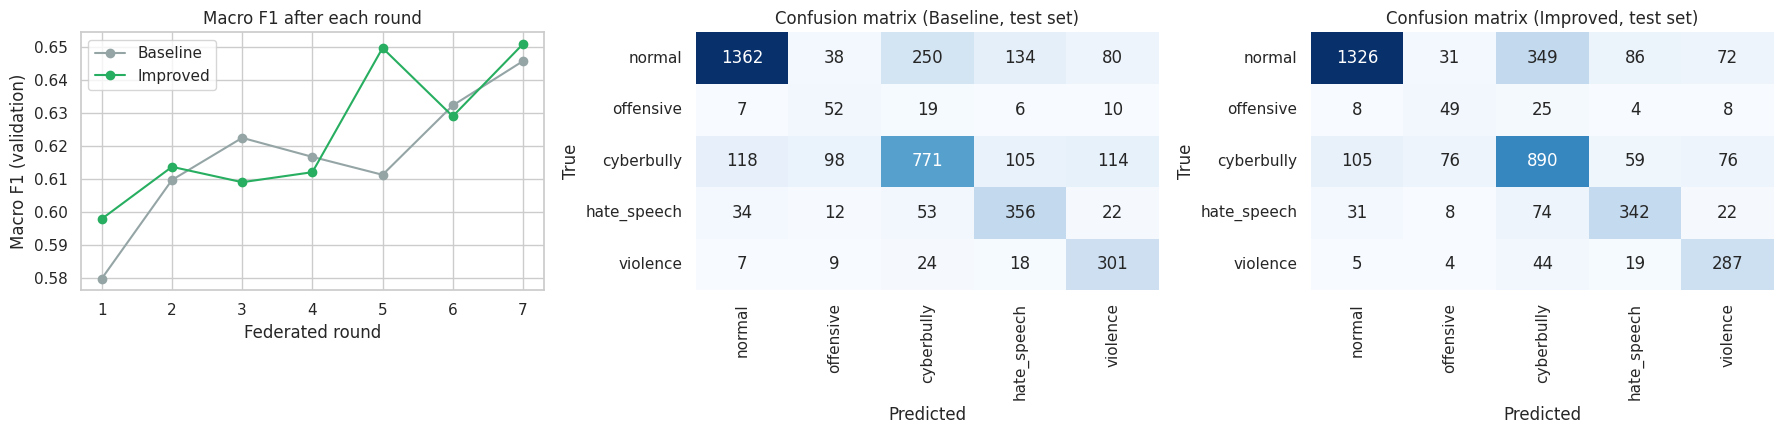

In [20]:
# ============================================================
# 6.4  Macro F1 per federated round + confusion matrices
# ============================================================
n_plots = 3 if RUN_BASELINE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4.5))

if RUN_BASELINE:
    axes[0].plot(baseline_history["round"], baseline_history["macro_f1"], "o-", label="Baseline", color="#95A5A6")
axes[0].plot(improved_history["round"], improved_history["macro_f1"], "o-", label="Improved", color="#27AE60")
axes[0].set_xlabel("Federated round"); axes[0].set_ylabel("Macro F1 (validation)")
axes[0].set_title("Macro F1 after each round"); axes[0].legend()
axes[0].set_xticks(improved_history["round"])

results_to_plot = ([("Baseline", baseline_result)] if RUN_BASELINE else []) + [("Improved", improved_result)]
for ax, (name, result) in zip(axes[1:], results_to_plot):
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=range(len(LABELS)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Confusion matrix ({name}, test set)")
fig.tight_layout()
save_fig(fig, "4_rounds_and_confusion_matrix")
plt.show()

In [21]:
# ============================================================
# 6.5  Scores per source + on the checked test labels, and save this run
# ============================================================
def scores(y_true, y_pred, labels=range(len(LABELS))):
    return {"rows": len(y_true), "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
            "macro_f1": round(float(f1_score(y_true, y_pred, labels=list(labels), average="macro", zero_division=0)), 4)}

y_true, y_pred = np.array(improved_result["y_true"]), np.array(improved_result["y_pred"])

# (a) Per source: macro F1 over the classes that source contains (e.g. VITD has only normal / violence)
per_source = {}
for source in sorted(test_df["source"].unique()):
    rows = (test_df["source"] == source).to_numpy()
    per_source[source] = scores(y_true[rows], y_pred[rows], labels=sorted(set(y_true[rows])))
print("Improved model, test set, per source:")
display(pd.DataFrame(per_source).T)

# (b) Checked labels: the test labels checked against the guideline (dataset/test_label_check.csv)
checked_result = {}
has_check = test_df["checked_label"].isin(LABELS).to_numpy() if "checked_label" in test_df else np.zeros(len(test_df), bool)
if has_check.any():
    y_checked = test_df.loc[has_check, "checked_label"].map(LABEL2ID).to_numpy()
    checked_result = scores(y_checked, y_pred[has_check])
    checked_result["per_class_f1"] = dict(zip(LABELS, f1_score(y_checked, y_pred[has_check], labels=range(len(LABELS)),
                                                               average=None, zero_division=0).round(4).tolist()))
    checked_result["source_label_agreement"] = round(float((y_checked == y_true[has_check]).mean()), 4)
    print(f"\nChecked test labels ({has_check.sum()} rows): macro F1 = {checked_result['macro_f1']:.4f} "
          f"(source labels: {scores(y_true[has_check], y_pred[has_check])['macro_f1']:.4f} on the same rows)")
    print(f"The source label agrees with the checked label for {checked_result['source_label_agreement']:.1%} of these rows.")
    print(pd.Series(checked_result["per_class_f1"]).to_string())
else:
    print("\nNo checked test labels in the dataset file yet.")

# (c) Save this run, so 6.6 can compare dataset versions and seeds
def to_plain(r):
    return {"macro_f1": round(float(r["macro_f1"]), 4), "accuracy": round(float(r["accuracy"]), 4),
            "per_class_f1": {k: float(v) for k, v in r["per_class_f1"].items()}}
run = {"data_version": DATA_VERSION, "seed": SEED, "run_mode": RUN_MODE, "train_rows": len(train_df),
       "improved": to_plain(improved_result), "oversampled_only": to_plain(oversampled_result),
       "baseline": to_plain(baseline_result) if RUN_BASELINE else None,
       "per_source": per_source, "checked": checked_result}
os.makedirs(os.path.join(OUT_DIR, "runs"), exist_ok=True)
run_path = os.path.join(OUT_DIR, "runs", f"{DATA_VERSION}_seed{SEED}_{RUN_MODE}.json")
with open(run_path, "w") as f:
    json.dump(run, f, indent=2)
print("\nRun saved:", run_path)


Improved model, test set, per source:


,rows,accuracy,macro_f1
banhate,586.0,0.6860,0.5345
bdshs,1546.0,0.6856,0.6173
belal,491.0,0.7413,0.6242
boc,1255.0,0.7729,0.7234
vitd,122.0,0.8033,0.8775



Checked test labels (3993 rows): macro F1 = 0.5450 (source labels: 0.6494 on the same rows)
The source label agrees with the checked label for 67.8% of these rows.
normal         0.7896
offensive      0.3306
cyberbully     0.6613
hate_speech    0.2534
violence       0.6900

Run saved: /content/drive/MyDrive/bangla_forensics_outputs/runs/C_seed42_FULL.json


In [22]:
# ============================================================
# 6.6  Compare dataset versions A / B / C over all saved runs (mean ± std over seeds)
# ============================================================
runs = [json.load(open(p)) for p in sorted(glob.glob(os.path.join(OUT_DIR, "runs", "*.json")))]
runs = [r for r in runs if r["run_mode"] == RUN_MODE]            # never mix QUICK and FULL numbers
rows = [{"version": r["data_version"], "seed": r["seed"], "train rows": r["train_rows"],
         "macro F1": r["improved"]["macro_f1"],
         "macro F1 (checked labels)": r["checked"].get("macro_f1", np.nan) if r["checked"] else np.nan,
         **{f"F1 {l}": r["improved"]["per_class_f1"][l] for l in LABELS}} for r in runs]
if rows:
    runs_df = pd.DataFrame(rows).sort_values(["version", "seed"])
    display(runs_df)
    metrics = [c for c in runs_df.columns if c.startswith(("macro", "F1"))]
    summary_runs = runs_df.groupby("version")[metrics].agg(["mean", "std"]).round(4)
    summary_runs.insert(0, ("seeds", ""), runs_df.groupby("version").size())
    display(summary_runs)
    summary_runs.to_csv(os.path.join(OUT_DIR, "dataset_version_comparison.csv"))
    print("A difference between versions only counts when it is clearly larger than the std between seeds.")
else:
    print("No saved runs yet.")


,version,seed,train rows,macro F1,macro F1 (checked labels),F1 normal,F1 offensive,F1 cyberbully,F1 hate_speech,F1 violence
0,C,42,27701,0.6491,0.545,0.7942,0.374,0.6878,0.693,0.6966


seeds macro F1     macro F1 (checked labels)     F1 normal      \
                  mean std                      mean std      mean std   
version                                                                  
C           1   0.6491 NaN                     0.545 NaN    0.7942 NaN   

        F1 offensive     F1 cyberbully     F1 hate_speech     F1 violence      
                mean std          mean std           mean std        mean std  
version                                                                        
C              0.374 NaN        0.6878 NaN          0.693 NaN      0.6966 NaN

A difference between versions only counts when it is clearly larger than the std between seeds.


---
# Section 7 · Novel part – end-to-end analysis of a comment

`analyze_texts()` runs the full chain: **clean → unmask → transliterate → classify → (if harmful) save to blockchain**.
The classifier uses the class thresholds tuned in 6.2, so the confidence below is the probability after that adjustment.

* A harmful prediction with confidence ≥ `EVIDENCE_MIN_CONFIDENCE` becomes an **EVIDENCE** block. The block stores the
  original text, its SHA-256 fingerprint, the normalised text, the prediction and the confidence.
* A harmful prediction with lower confidence is marked **uncertain** (for a human to review) and is not saved.

In [23]:
# ============================================================
# 7.1  Analyse texts and record evidence   (examples from the problem statement)
# ============================================================
def analyze_texts(texts, save_to_blockchain=True, context=None):
    """Run the whole pipeline on a list of texts.
    context: optional list of dicts (one per text) with extra info, e.g. user id and time."""
    texts = [str(t) for t in texts]
    normalized, steps = [], []
    for t in texts:
        final_text, s = normalize_text(t)
        normalized.append(final_text); steps.append(s)
    probs = adjust_probs(predict_proba(model, normalized), CLASS_BIAS)   # thresholds tuned in 6.2

    rows = []
    for i, text in enumerate(texts):
        label = LABELS[int(probs[i].argmax())]
        confidence = round(float(probs[i].max()), 4)
        is_harmful = label != "normal" and confidence >= EVIDENCE_MIN_CONFIDENCE
        decision = ("normal" if label == "normal" else
                    "EVIDENCE" if is_harmful else "uncertain (review)")
        row = {**steps[i], "prediction": label, "confidence": confidence,
               "decision": decision, "is_harmful": is_harmful, "block_index": None}
        if save_to_blockchain and is_harmful:
            block = ledger.add_block("EVIDENCE", {
                "original_text": text,
                "text_sha256": sha256(text),          # proves the text was not changed later
                "normalized_text": normalized[i],
                "prediction": label,
                "confidence": confidence,
                **(context[i] if context else {"source": "manual_input"}),
            })
            row["block_index"] = block["index"]
        rows.append(row)
    return pd.DataFrame(rows).astype({"block_index": "Int64"})   # Int64 = whole numbers, empty allowed

examples = ["kutt*r bacc*", "কুত্*ার বাচ্চা", "Ami tomake bhalobasi", "আজ আবহাওয়া খুব সুন্দর"]
demo_results = analyze_texts(examples)
display(demo_results.drop(columns=["cleaned", "is_harmful"]))
print("Blocks in the ledger:", dict(ledger.count_by_type()))

# Show one evidence block exactly as it is stored in the blockchain
evidence_index = demo_results["block_index"].dropna()
if len(evidence_index):
    print("\nEvidence block as stored in the blockchain:")
    print(json.dumps(ledger.chain[int(evidence_index.iloc[0])], ensure_ascii=False, indent=2))

,input,unmasked,transliterated,prediction,confidence,decision,block_index
0,kutt*r bacc*,kuttar baccha,কুত্তার বাচ্চা,cyberbully,0.9981,EVIDENCE,57
1,কুত্*ার বাচ্চা,কুত্তার বাচ্চা,কুত্তার বাচ্চা,cyberbully,0.9981,EVIDENCE,58
2,Ami tomake bhalobasi,Ami tomake bhalobasi,আমি তোমাকে ভালোবাসি,normal,0.9996,normal,<NA>
3,আজ আবহাওয়া খুব সুন্দর,আজ আবহাওয়া খুব সুন্দর,আজ আবহাওয়া খুব সুন্দর,normal,0.9995,normal,<NA>


Blocks in the ledger: {'GENESIS': 1, 'CLIENT_UPDATE': 42, 'GLOBAL_MODEL': 14, 'EVIDENCE': 2}

Evidence block as stored in the blockchain:
{
  "index": 57,
  "timestamp": "2026-10-02T17:42:19.799837+00:00",
  "type": "EVIDENCE",
  "data": {
    "original_text": "kutt*r bacc*",
    "text_sha256": "ac4f7dec25afc6cd15157a14457c62bb577cc365ff99eba1cc319fcf1a967879",
    "normalized_text": "কুত্তার বাচ্চা",
    "prediction": "cyberbully",
    "confidence": 0.9981,
    "source": "manual_input"
  },
  "previous_hash": "0096d30306bf19d79f85eee34996a29246a44783709fe507f22c5bf3a5410f6a",
  "nonce": 30,
  "hash": "0050227b0f7e95c5ce5470a3ef02528c18ed4b033158f733f97a592c60d9c5c8"
}


In [24]:
# ============================================================
# 7.2  Interactive analysis of a single comment
# ============================================================
# The input may be Bangla or Romanized Bangla and may contain words hidden with '*', e.g.:
#   "tui ekta sh*la"   |   "এই শু*রের বাচ্চা"   |   "kemon acho bhai"
MY_COMMENT = "tui ekta sh*la"          # @param {type:"string"}
SAVE_AS_EVIDENCE = False               # @param {type:"boolean"}

live = analyze_texts([MY_COMMENT], save_to_blockchain=SAVE_AS_EVIDENCE).iloc[0]
print("Input          :", live["input"])
print("Unmasked       :", live["unmasked"])
print("Transliterated :", live["transliterated"])
print("Prediction     :", live["prediction"], f"(confidence {live['confidence']:.2f})")
print("Decision       :", live["decision"],
      f"-> saved as block #{live['block_index']}" if pd.notna(live["block_index"]) else "")

Input          : tui ekta sh*la
Unmasked       : tui ekta shala
Transliterated : তুই একটা শালা
Prediction     : cyberbully (confidence 1.00)
Decision       : EVIDENCE 


---
# Section 8 · Requirement: DF analysis of a Facebook user account

This section implements the requirement: it monitors the activities of a **public** account (status, share, comment) as **time-series data**, keeps its public **About / personal info**, and builds a **profile with 5 aspects**. Every activity is first processed by the novel pipeline (Sections 2 and 7), so hidden and Romanized harmful comments are also detected.

```
Public Facebook account
 ├── About: public profile information (visibility, joined, followers ...)
 └── Activities with date/time  ──►  TIME-SERIES DATA
       • status  (the user writes a post)
       • share   (the user shares someone else's post)
       • comment (the user comments on other people's posts)
              │  every activity: clean → unmask → transliterate → classify
              ▼
 PROFILING with 5 aspects  ──►  profile vector  ──►  risk level (Low / Medium / High)
              │
              ▼
 BLOCKCHAIN: one EVIDENCE block per harmful activity + one USER_PROFILE block
```

**Input format.** A CSV file with the columns `user_id, timestamp, activity_type, text`
(`activity_type` is `status`, `share` or `comment`). The file is selected with `USER_ACTIVITY_CSV` in cell 8.1.

**Ethics.** Only **public** data, collected lawfully (e.g. by an investigator with legal authority). This notebook does
**not** scrape Facebook. Without a CSV it creates **simulated** accounts from real test-set comments, clearly marked as simulated.

**Simulated accounts:**

| User | Behaviour built into the simulation | Expected result |
|---|---|---|
| `user_A` | ordinary user, about 5% harmful posts | **Low** risk |
| `user_B` | harmful posts grow from 5% to 70% over 12 weeks | **escalating** trend |
| `user_C` | half of the posts harmful, mostly comments on others, uses hidden words | **harasser** role |

In [25]:
# ============================================================
# 8.1  Load (or simulate) the public activity of user accounts
# ============================================================
USER_ACTIVITY_CSV = None     # e.g. "user_activity.csv" ; None = use simulated accounts

# Public "About" information of each account (context in the report, not used in the score)
USER_ABOUT = {}

def simulate_user(user_id, weeks, posts_per_week, harm_start, harm_end, harm_types, type_probs, extra=()):
    """Create a SIMULATED public timeline from real test-set comments.
    harm_start / harm_end = chance that a post is harmful in the first / last week
    (for example 0.05 -> 0.70 gives an 'escalating' user)."""
    user_seed = SEED + sum(map(ord, user_id))              # same result every run
    rng, np_rng = random.Random(user_seed), np.random.default_rng(user_seed)
    texts_by_label = {l: test_df.loc[test_df["label"] == l, "text"].tolist() for l in LABELS}
    start = datetime(2026, 1, 5)
    rows = []
    for week in range(weeks):
        p_harm = harm_start + (harm_end - harm_start) * week / max(weeks - 1, 1)
        for _ in range(np_rng.poisson(posts_per_week)):     # number of posts this week
            label = rng.choice(harm_types) if rng.random() < p_harm else "normal"
            pool = texts_by_label[label] or texts_by_label["normal"]
            rows.append({
                "user_id": user_id,
                "timestamp": start + timedelta(weeks=week, hours=rng.randint(0, 7 * 24 - 1)),
                "activity_type": rng.choices(["status", "share", "comment"], weights=type_probs)[0],
                "text": rng.choice(pool),
                "true_label": label,          # known only because the data is simulated
            })
    # Extra (e.g. obfuscated) comments placed in the last week
    for text in extra:
        rows.append({"user_id": user_id, "timestamp": start + timedelta(weeks=weeks - 1, hours=rng.randint(0, 150)),
                     "activity_type": "comment", "text": text, "true_label": "offensive"})
    return pd.DataFrame(rows)

if USER_ACTIVITY_CSV:
    activity = pd.read_csv(USER_ACTIVITY_CSV, parse_dates=["timestamp"])
    missing = {"user_id", "timestamp", "activity_type", "text"} - set(activity.columns)
    assert not missing, f"The CSV is missing these columns: {missing}"
    activity["activity_type"] = activity["activity_type"].str.strip().str.lower()
    SIMULATED_EXPECTATION = {}
else:
    print("Using SIMULATED accounts (no real user data).")
    activity = pd.concat([
        # A: ordinary user - almost never harmful
        simulate_user("user_A", 12, 5, 0.05, 0.05, ["offensive"], [0.5, 0.3, 0.2]),
        # B: escalating user - harmful posts increase over time
        simulate_user("user_B", 12, 5, 0.05, 0.70, ["offensive", "hate_speech", "violence"], [0.4, 0.4, 0.2]),
        # C: harasser - many harmful comments on other people's posts, with hidden bad words
        simulate_user("user_C", 12, 5, 0.50, 0.50, ["cyberbully", "offensive"], [0.1, 0.1, 0.8],
                      extra=["kutt*r bacc*", "কুত্*ার বাচ্চা"]),
    ], ignore_index=True)
    USER_ABOUT = {
        "user_A": {"profile": "public", "joined": "2018-04", "followers": 320, "simulated": True},
        "user_B": {"profile": "public", "joined": "2024-11", "followers": 1450, "simulated": True},
        "user_C": {"profile": "public", "joined": "2025-08", "followers": 45, "simulated": True},
    }
    # What the simulation was built to show (checked automatically in 8.3)
    SIMULATED_EXPECTATION = {"user_A": ("risk level", "Low"),
                             "user_B": ("trend", "escalating"),
                             "user_C": ("role", "harasser (harmful comments on others)")}

activity = activity.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
print("Activities per user and type:")
print(activity.groupby(["user_id", "activity_type"]).size().unstack(fill_value=0))
activity.head()

Using SIMULATED accounts (no real user data).
Activities per user and type:
activity_type  comment  share  status
user_id                              
user_A              12     15      31
user_B               7     23      24
user_C              57      4       8


,user_id,timestamp,activity_type,text,true_label
0,user_A,2026-01-05 22:00:00,share,জয় ভাইয়া আপনি আমার পছন্দের একজন কিন্তু আজ এই...,normal
1,user_A,2026-01-07 09:00:00,status,"সিঁড়ি দিয়ে নেমে হাঁপিয়ে উঠার কারণে, আমার জি...",normal
2,user_A,2026-01-09 10:00:00,comment,চারজন কুত্তা মিলে একজন ইমানদার কে ধরেছে,offensive
3,user_A,2026-01-09 15:00:00,share,"হিরো আলম ভাইয়া,,,,,, আমি আপনার সাথে কথা বলতে চাই",normal
4,user_A,2026-01-14 22:00:00,status,বইগুলো ফেরত দিলাম তাদের...বললাম ভাগ সামনে থেকে,normal


In [26]:
# ============================================================
# 8.2  Analyse every activity (harmful ones become EVIDENCE blocks)
# ============================================================
context = [{"user_id": r.user_id, "activity_type": r.activity_type, "timestamp": str(r.timestamp)}
           for r in activity.itertuples()]
results = analyze_texts(activity["text"].tolist(), save_to_blockchain=True, context=context)

activity["normalized_text"] = results["transliterated"].values
activity["prediction"]      = results["prediction"].values
activity["confidence"]      = results["confidence"].values
activity["decision"]        = results["decision"].values
activity["is_harmful"]      = results["is_harmful"].values
activity["block_index"]     = results["block_index"].values
activity["week"]            = activity["timestamp"].dt.to_period("W").dt.start_time   # time-series step

print(f"Activities analysed: {len(activity)} | harmful (evidence): {int(activity['is_harmful'].sum())} "
      f"| uncertain: {int((activity['decision'] == 'uncertain (review)').sum())}")

# With simulated data the true label is known, so we can check the detection
if "true_label" in activity:
    truly_harmful = activity["true_label"] != "normal"
    print(f"Check on simulated data: harmful / normal decided correctly for "
          f"{(truly_harmful == activity['is_harmful']).mean():.1%} of the activities")
    print(pd.crosstab(truly_harmful.map({True: "truly harmful", False: "truly normal"}),
                      activity["is_harmful"].map({True: "detected harmful", False: "detected normal"})))

activity[["user_id", "timestamp", "activity_type", "normalized_text", "prediction", "decision", "block_index"]].tail(8)

Activities analysed: 181 | harmful (evidence): 82 | uncertain: 10
Check on simulated data: harmful / normal decided correctly for 74.6% of the activities
is_harmful     detected harmful  detected normal
true_label                                      
truly harmful                48               12
truly normal                 34               87


,user_id,timestamp,activity_type,normalized_text,prediction,decision,block_index
173,user_C,2026-03-22 01:00:00,comment,ভাই আমরা জতই লিখি আসামিদের কিছু জারজ নেতা আছে ...,offensive,EVIDENCE,135
174,user_C,2026-03-22 07:00:00,comment,বর্জন করা উচিত এই বদমাশটাকে ইহুদির চর,cyberbully,uncertain (review),<NA>
175,user_C,2026-03-23 00:00:00,comment,মাগি গুলা যে সেকেন্ডে সেকেন্ডে নাগিনের মত রুপ ...,cyberbully,EVIDENCE,136
176,user_C,2026-03-25 20:00:00,comment,কুত্তার বাচ্চা,cyberbully,EVIDENCE,137
177,user_C,2026-03-26 16:00:00,comment,এইটা তো কুতা লিগের কাজ,offensive,EVIDENCE,138
178,user_C,2026-03-26 19:00:00,comment,"বয়স থেকে লাভ নেই , এরা দেশের আবর্জনা , ক্রসফা...",violence,EVIDENCE,139
179,user_C,2026-03-27 12:00:00,comment,কুত্তার বাচ্চা,cyberbully,EVIDENCE,140
180,user_C,2026-03-27 21:00:00,share,আগে আপনার ফার্মের শ্রমিকদের ৪ মাসের বেতন পরিশো...,normal,normal,<NA>


In [27]:
# ============================================================
# 8.3  Build the forensic profile (5 aspects)
# ============================================================
# Severity of each class (0 = harmless ... 4 = most serious). An analyst can change these.
SEVERITY = {"normal": 0, "offensive": 1, "cyberbully": 2, "hate_speech": 3, "violence": 4}

def risk_score(harm_ratio, severity, rise):
    """Risk score (0-100): harmful ratio 50%, harm load 30%, rising trend 20%.
    Harm load = harmful ratio x severity, so a user with only a few harmful posts gets only
    a few points for severity, even when those posts are serious."""
    return 100 * (0.5 * harm_ratio + 0.3 * harm_ratio * severity + 0.2 * min(max(rise, 0.0), 1.0))

# Cut-offs = the score of a stable user (no rise) whose harmful posts have medium severity (0.5):
#   Medium from 20% harmful activity - the classifier alone marks about 10-15% of normal comments
#          as harmful (confusion matrix in 6.4), so a lower ratio cannot be told apart from its mistakes;
#   High   from 50% harmful activity - half of everything the user posts.
RISK_MEDIUM = risk_score(0.20, 0.5, 0.0)    # 13.0
RISK_HIGH   = risk_score(0.50, 0.5, 0.0)    # 32.5

ROLE = {"status": "author (writes harmful posts)",
        "share": "spreader (shares harmful content)",
        "comment": "harasser (harmful comments on others)"}

def build_user_profile(user_df):
    harmful = user_df[user_df["is_harmful"]]
    weekly = user_df.groupby("week").agg(posts=("is_harmful", "size"), harmful=("is_harmful", "sum"))
    weekly["harm_ratio"] = weekly["harmful"] / weekly["posts"]

    # Aspect 1: activity level - how many posts per week, and at which hour most often
    posts_per_week = weekly["posts"].mean()
    peak_hour = int(user_df["timestamp"].dt.hour.mode()[0])

    # Aspect 2: harmful ratio - share of all activities that are harmful
    harm_ratio = user_df["is_harmful"].mean()

    # Aspect 3: harm type and severity (0..1)
    harm_types = {k: int(v) for k, v in harmful["prediction"].value_counts().items()}
    main_type = harmful["prediction"].mode()[0] if len(harmful) else "none"
    severity = harmful["prediction"].map(SEVERITY).mean() / max(SEVERITY.values()) if len(harmful) else 0.0

    # Aspect 4: time trend = straight line through the weekly harmful ratio.
    # "rise" = how much the ratio grew from the first to the last week.
    slope = np.polyfit(np.arange(len(weekly)), weekly["harm_ratio"], 1)[0] if len(weekly) > 1 else 0.0
    rise = slope * (len(weekly) - 1)
    trend = "escalating" if rise > 0.15 else ("decreasing" if rise < -0.15 else "stable")

    # Aspect 5: behaviour channel - where does the harmful content appear?
    channel = harmful["activity_type"].value_counts(normalize=True).round(2).to_dict()
    role = ROLE.get(max(channel, key=channel.get), "none") if channel else "none"

    risk = risk_score(harm_ratio, severity, rise)
    level = "High" if risk >= RISK_HIGH else ("Medium" if risk >= RISK_MEDIUM else "Low")

    return {
        "1_activity":  {"posts_per_week": round(float(posts_per_week), 2), "peak_hour": peak_hour,
                        "total_activities": int(len(user_df))},
        "2_harmful_ratio": round(float(harm_ratio), 3),
        "3_harm_type": {"main_type": main_type, "counts": harm_types, "severity": round(float(severity), 3)},
        "4_trend":     {"trend": trend, "rise": round(float(rise), 3)},
        "5_channel":   {"share_by_type": channel, "role": role},
        "profile_vector": [round(float(v), 3) for v in
                           [posts_per_week, harm_ratio, severity, rise,
                            channel.get("status", 0), channel.get("share", 0), channel.get("comment", 0)]],
        "risk_score": round(float(risk), 1),
        "risk_level": level,
        "weekly": weekly,
    }

profiles = {uid: build_user_profile(udf) for uid, udf in activity.groupby("user_id")}

# Summary table: one row per user
summary = pd.DataFrame([{
    "user": uid,
    "joined": USER_ABOUT.get(uid, {}).get("joined", "?"),
    "followers": USER_ABOUT.get(uid, {}).get("followers", "?"),
    "posts/week": p["1_activity"]["posts_per_week"],
    "harmful ratio": p["2_harmful_ratio"],
    "main harm type": p["3_harm_type"]["main_type"],
    "severity": p["3_harm_type"]["severity"],
    "trend": p["4_trend"]["trend"],
    "role": p["5_channel"]["role"],
    "risk score": p["risk_score"],
    "risk level": p["risk_level"],
} for uid, p in profiles.items()]).set_index("user")

# Simulated data: does the profile show what the simulation was built to show?
if SIMULATED_EXPECTATION:
    summary["expected (simulation)"] = [" = ".join(SIMULATED_EXPECTATION[u]) for u in summary.index]
    summary["found?"] = ["yes" if summary.loc[u, SIMULATED_EXPECTATION[u][0]] == SIMULATED_EXPECTATION[u][1]
                         else "no" for u in summary.index]

summary.to_csv(os.path.join(OUT_DIR, "user_profiles_summary.csv"))
display(summary)

,joined,followers,posts/week,harmful ratio,main harm type,severity,trend,role,risk score,risk level,expected (simulation),found?
user,,,,,,,,,,,,
user_A,2018-04,320,4.83,0.293,cyberbully,0.559,stable,author (writes harmful posts),19.6,Medium,risk level = Low,no
user_B,2024-11,1450,4.50,0.481,cyberbully,0.635,escalating,author (writes harmful posts),44.0,High,trend = escalating,yes
user_C,2025-08,45,5.75,0.565,cyberbully,0.506,stable,harasser (harmful comments on others),38.6,High,role = harasser (harmful comments on others),yes


Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/5_timeline_user_A.png


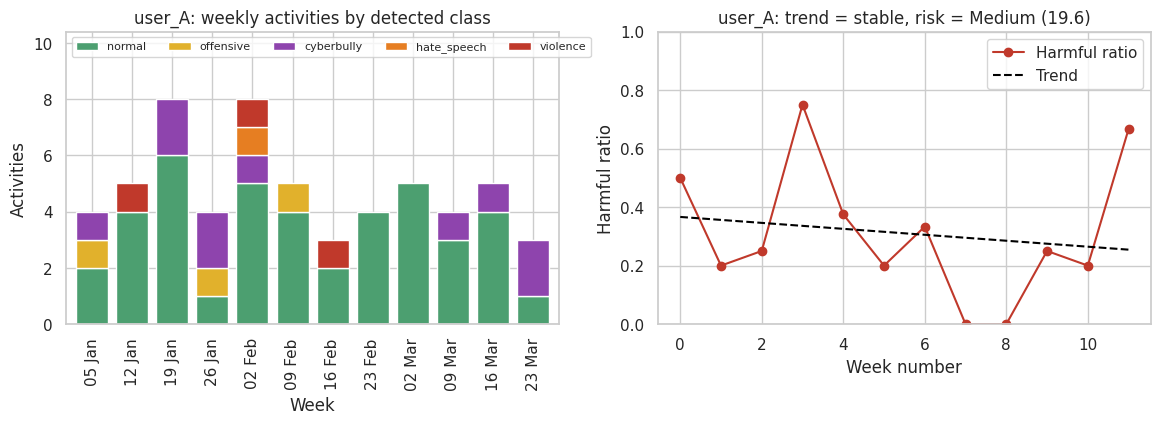

Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/5_timeline_user_B.png


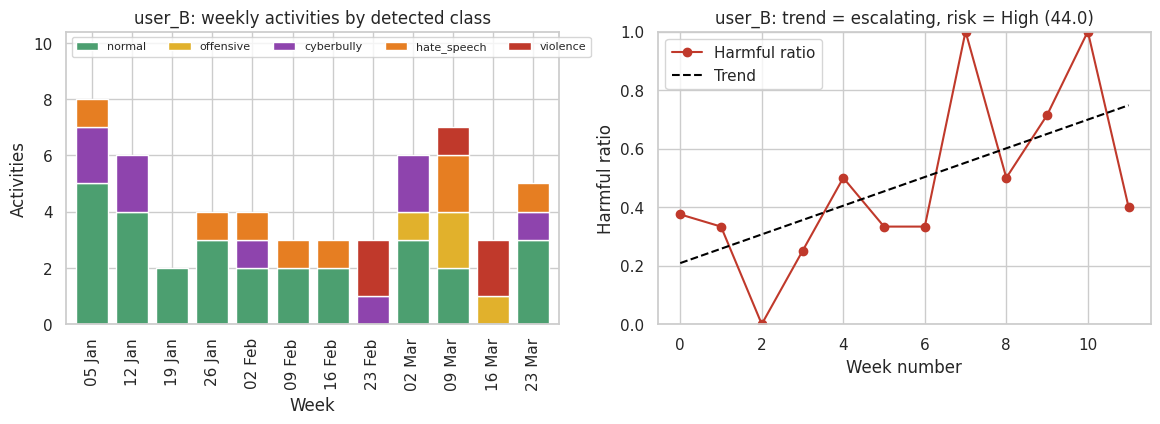

Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/5_timeline_user_C.png


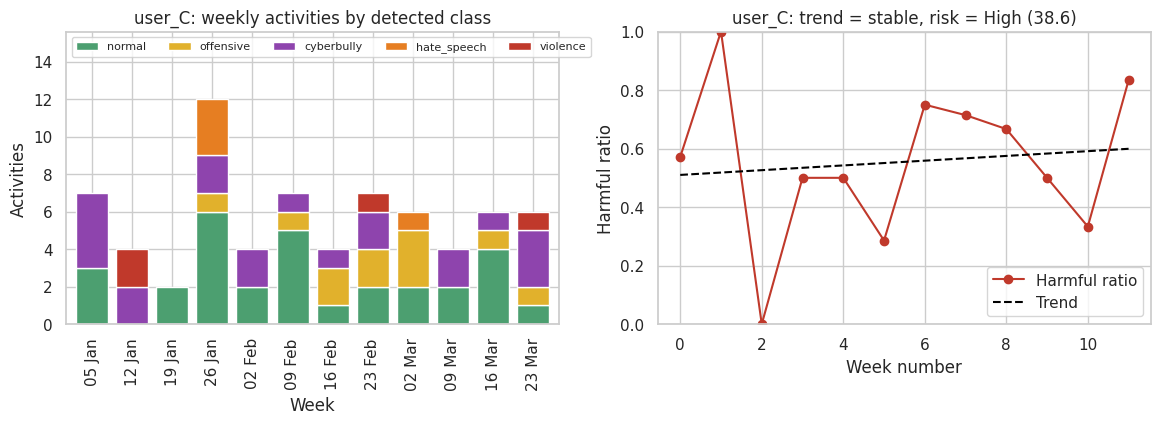

Figure saved: /content/drive/MyDrive/bangla_forensics_outputs/figures/6_user_risk_scores.png


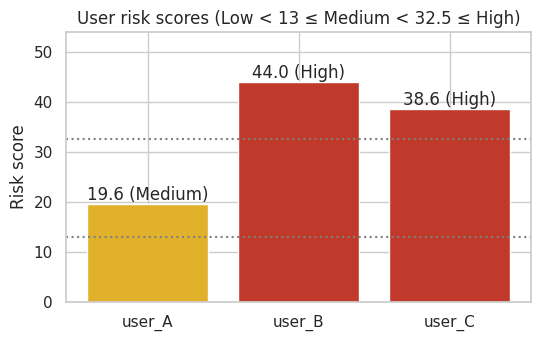

In [28]:
# ============================================================
# 8.4  Time-series charts for every user
# ============================================================
for uid, user_df in activity.groupby("user_id"):
    weekly_counts = (user_df.assign(shown=np.where(user_df["is_harmful"], user_df["prediction"], "normal"))
                     .groupby(["week", "shown"]).size().unstack(fill_value=0)
                     .reindex(columns=LABELS, fill_value=0))
    weekly = profiles[uid]["weekly"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
    weekly_counts.index = weekly_counts.index.strftime("%d %b")
    weekly_counts.plot(kind="bar", stacked=True, ax=axes[0], width=0.8,
                       color=[CLASS_COLORS[c] for c in LABELS])
    axes[0].set_title(f"{uid}: weekly activities by detected class")
    axes[0].set_xlabel("Week"); axes[0].set_ylabel("Activities")
    axes[0].set_ylim(0, weekly_counts.sum(axis=1).max() * 1.3)    # space for the legend
    axes[0].legend(fontsize=8, ncol=5, loc="upper left")

    x = np.arange(len(weekly))
    axes[1].plot(x, weekly["harm_ratio"], "o-", color="#C0392B", label="Harmful ratio")
    if len(weekly) > 1:
        a, b = np.polyfit(x, weekly["harm_ratio"], 1)
        axes[1].plot(x, a * x + b, "--", color="black", label="Trend")
    axes[1].set_ylim(0, 1); axes[1].set_xlabel("Week number"); axes[1].set_ylabel("Harmful ratio")
    axes[1].set_title(f"{uid}: trend = {profiles[uid]['4_trend']['trend']}, "
                      f"risk = {profiles[uid]['risk_level']} ({profiles[uid]['risk_score']})")
    axes[1].legend()
    save_fig(fig, f"5_timeline_{uid}")
    plt.show()

# Risk score of all users
fig, ax = plt.subplots(figsize=(6, 3.5))
colors = {"Low": "#27AE60", "Medium": "#E1B12C", "High": "#C0392B"}
bars = ax.bar(summary.index, summary["risk score"], color=[colors[l] for l in summary["risk level"]])
ax.bar_label(bars, labels=[f"{s} ({l})" for s, l in zip(summary["risk score"], summary["risk level"])])
ax.axhline(RISK_MEDIUM, ls=":", color="gray"); ax.axhline(RISK_HIGH, ls=":", color="gray")
ax.set_ylim(0, max(50, summary["risk score"].max() + 10)); ax.set_ylabel("Risk score")
ax.set_title(f"User risk scores (Low < {RISK_MEDIUM:g} ≤ Medium < {RISK_HIGH:g} ≤ High)")
save_fig(fig, "6_user_risk_scores")
plt.show()

In [29]:
# ============================================================
# 8.5  Store every profile in the blockchain + print the forensic report
# ============================================================
profile_records = {}
for uid, p in profiles.items():
    user_df = activity[activity["user_id"] == uid]
    record = {
        "user_id": uid,
        "about": USER_ABOUT.get(uid, {}),
        "period": f"{user_df['timestamp'].min():%Y-%m-%d} to {user_df['timestamp'].max():%Y-%m-%d}",
        **{k: v for k, v in p.items() if k != "weekly"},
        "evidence_blocks": user_df["block_index"].dropna().astype(int).tolist(),  # links to EVIDENCE blocks
    }
    block = ledger.add_block("USER_PROFILE", record)
    record["profile_block"] = block["index"]
    profile_records[uid] = record

    a, h, t, c = p["1_activity"], p["3_harm_type"], p["4_trend"], p["5_channel"]
    print("=" * 72)
    print(f"FORENSIC PROFILE: {uid}      (blockchain block #{block['index']}, hash {block['hash'][:16]}...)")
    print("=" * 72)
    print("About            :", ", ".join(f"{k}: {v}" for k, v in record["about"].items()) or "-")
    print("Period           :", record["period"])
    print(f"1. Activity      : {a['total_activities']} activities, {a['posts_per_week']} per week, "
          f"most active at {a['peak_hour']:02d}:00")
    print(f"2. Harmful ratio : {p['2_harmful_ratio']:.1%} of the activities are harmful")
    print(f"3. Harm type     : mostly {h['main_type']}  {h['counts']}  (severity {h['severity']})")
    print(f"4. Trend         : {t['trend']}  (harmful ratio changed by {t['rise']:+.2f} over the period)")
    print(f"5. Channel       : {c['role']}  {c['share_by_type']}")
    print("Profile vector   :", p["profile_vector"], " [posts/week, harm ratio, severity, rise, status, share, comment]")
    print(f"RISK             : {p['risk_score']} -> {p['risk_level']}")
    print(f"Evidence blocks  : {len(record['evidence_blocks'])} blocks, e.g. {record['evidence_blocks'][:10]}")
    print()

with open(os.path.join(OUT_DIR, "user_profiles.json"), "w", encoding="utf-8") as f:
    json.dump(profile_records, f, ensure_ascii=False, indent=2, default=str)

FORENSIC PROFILE: user_A      (blockchain block #141, hash 00c2b2fe0932890d...)
About            : profile: public, joined: 2018-04, followers: 320, simulated: True
Period           : 2026-01-05 to 2026-03-27
1. Activity      : 58 activities, 4.83 per week, most active at 04:00
2. Harmful ratio : 29.3% of the activities are harmful
3. Harm type     : mostly cyberbully  {'cyberbully': 10, 'offensive': 3, 'violence': 3, 'hate_speech': 1}  (severity 0.559)
4. Trend         : stable  (harmful ratio changed by -0.11 over the period)
5. Channel       : author (writes harmful posts)  {'status': 0.47, 'share': 0.35, 'comment': 0.18}
Profile vector   : [4.833, 0.293, 0.559, -0.112, 0.47, 0.35, 0.18]  [posts/week, harm ratio, severity, rise, status, share, comment]
RISK             : 19.6 -> Medium
Evidence blocks  : 17 blocks, e.g. [59, 60, 61, 62, 63, 64, 65, 66, 67, 68]

FORENSIC PROFILE: user_B      (blockchain block #142, hash 003f7d1b385a5204...)
About            : profile: public, joined:

---
# Section 9 · Verify the blockchain, save everything, requirement checklist

In [30]:
# ============================================================
# 9.1  Integrity check + tamper test
# ============================================================
print("Blocks by type:", dict(ledger.count_by_type()))
ledger_ok = ledger.verify()
print("Real ledger   :", ledger_ok)

# Tamper test: change one evidence block in a COPY of the chain and check again
tampered = copy.deepcopy(ledger)
evidence_ids = [b["index"] for b in tampered.chain if b["type"] == "EVIDENCE"]
if evidence_ids:                                   # someone tries to hide the evidence
    target = evidence_ids[0]
    print(f"\nSomeone changes block {target}: prediction "
          f"'{tampered.chain[target]['data']['prediction']}' -> 'normal'")
    tampered.chain[target]["data"]["prediction"] = "normal"
else:                                              # no evidence yet: change a training record instead
    target = 1
    print(f"\nSomeone changes block {target}: train_loss -> 0.0")
    tampered.chain[target]["data"]["train_loss"] = 0.0
tamper_result = tampered.verify()
print("Tampered copy :", tamper_result)

Blocks by type: {'GENESIS': 1, 'CLIENT_UPDATE': 42, 'GLOBAL_MODEL': 14, 'EVIDENCE': 84, 'USER_PROFILE': 3}
Real ledger   : (True, 'All 144 blocks are valid')

Someone changes block 57: prediction 'cyberbully' -> 'normal'
Tampered copy : (False, 'Block 57 was changed (hash does not match its data)')


In [31]:
# ============================================================
# 9.2  Output files
# ============================================================
activity.drop(columns=["week"]).to_csv(os.path.join(OUT_DIR, "user_activity_analysed.csv"), index=False)
for root, _, files in os.walk(OUT_DIR):
    if "final_classifier" in root or "banglat5" in root:
        continue
    for name in sorted(files):
        print(os.path.join(root, name))
print("\nModels:", os.path.join(OUT_DIR, "final_classifier"),
      "| BanglaT5:", T5_DIR if TRAIN_BANGLAT5 else "not trained (QUICK mode)")
print(f"\nDataset version {DATA_VERSION} | seed {SEED} | run mode {RUN_MODE}")

/content/drive/MyDrive/bangla_forensics_outputs/dataset_version_comparison.csv
/content/drive/MyDrive/bangla_forensics_outputs/forensic_blockchain.json
/content/drive/MyDrive/bangla_forensics_outputs/per_class_f1.csv
/content/drive/MyDrive/bangla_forensics_outputs/user_activity_analysed.csv
/content/drive/MyDrive/bangla_forensics_outputs/user_profiles.json
/content/drive/MyDrive/bangla_forensics_outputs/user_profiles_summary.csv
/content/drive/MyDrive/bangla_forensics_outputs/figures/1_class_distribution.png
/content/drive/MyDrive/bangla_forensics_outputs/figures/2_balancing.png
/content/drive/MyDrive/bangla_forensics_outputs/figures/3_per_class_f1.png
/content/drive/MyDrive/bangla_forensics_outputs/figures/4_rounds_and_confusion_matrix.png
/content/drive/MyDrive/bangla_forensics_outputs/figures/5_timeline_user_A.png
/content/drive/MyDrive/bangla_forensics_outputs/figures/5_timeline_user_B.png
/content/drive/MyDrive/bangla_forensics_outputs/figures/5_timeline_user_C.png
/content/drive/

In [32]:
# ============================================================
# 9.3  Requirement checklist (filled in from the results of THIS run)
# ============================================================
def check(ok):
    return "✔" if ok else "✘"

ex1, ex2 = demo_results.iloc[0], demo_results.iloc[1]
checklist = [
    ("Requirement", "Public account + About info", "8.1",
     check(all(uid in USER_ABOUT for uid in profiles)), f"{len(USER_ABOUT)} accounts with About info"),
    ("Requirement", "Monitoring activities: status / share / comment", "8.1–8.2",
     check(set(activity["activity_type"]) >= {"status", "share", "comment"}),
     str(activity["activity_type"].value_counts().to_dict())),
    ("Requirement", "Activities as time-series data", "8.2, 8.4",
     check(activity["week"].nunique() > 1), f"{activity['week'].nunique()} weeks, weekly charts per user"),
    ("Requirement", "Profiling with 5 aspects -> profile vector", "8.3",
     check(all(len(p["profile_vector"]) == 7 for p in profiles.values())), "activity, harm ratio, type, trend, channel"),
    ("Requirement", "Result: activity profile + risk level", "8.3–8.5",
     check(len(summary) > 0), ", ".join(f"{u}: {l}" for u, l in summary["risk level"].items())),
    ("Novel", "kutt*r bacc*  ->  কুত্তার বাচ্চা", "2.5, 7.1",
     check(ex1["transliterated"] == "কুত্তার বাচ্চা"), ex1["transliterated"]),
    ("Novel", "কুত্*ার বাচ্চা  ->  কুত্তার বাচ্চা", "2.5, 7.1",
     check(ex2["transliterated"] == "কুত্তার বাচ্চা"), ex2["transliterated"]),
    ("Novel", "Both classified as harmful and saved in the blockchain", "7.1",
     check(pd.notna(ex1["block_index"]) and pd.notna(ex2["block_index"])),
     f"{ex1['prediction']} ({ex1['confidence']:.2f}), {ex2['prediction']} ({ex2['confidence']:.2f})"),
    ("Novel", "Problem 1: class imbalance reduced (training set)", "4.2",
     check(imbalance(after) < imbalance(before)),
     f"normal / smallest class: {imbalance(before):.1f}x -> {imbalance(after):.1f}x"),
    ("Novel", "Problem 2: macro F1 improved (test set)", "6.3",
     check(RUN_BASELINE and improved_result["macro_f1"] > baseline_result["macro_f1"]),
     f"{baseline_result['macro_f1']:.3f} -> {improved_result['macro_f1']:.3f}" if RUN_BASELINE else "baseline skipped"),
    ("Novel", "Problem 2: F1 improved for the harmful classes", "6.3",
     check(RUN_BASELINE and all(table.loc[l, "change"] > 0 for l in LABELS[1:])),
     ", ".join(f"{l}: {table.loc[l, 'change']:+.2f}" for l in LABELS) if RUN_BASELINE else "baseline skipped"),
    ("Shared", "Federated learning (clients never share data)", "5",
     check(ledger.count_by_type()["CLIENT_UPDATE"] > 0),
     f"{NUM_CLIENTS} clients, {FL_ROUNDS} rounds, {ledger.count_by_type()['CLIENT_UPDATE']} client updates"),
    ("Shared", "Blockchain valid + tampering detected", "9.1",
     check(ledger_ok[0] and not tamper_result[0]), tamper_result[1]),
]
checklist = pd.DataFrame(checklist, columns=["part", "requirement", "cell", "ok", "result in this run"])
if SIMULATED_EXPECTATION:
    extra = pd.DataFrame([("Requirement", f"Simulated {u} shows: {c} = {v}", "8.3",
                           check(summary.loc[u, "found?"] == "yes"), str(summary.loc[u, c]))
                          for u, (c, v) in SIMULATED_EXPECTATION.items()], columns=checklist.columns)
    checklist = pd.concat([checklist, extra], ignore_index=True)
checklist.to_csv(os.path.join(OUT_DIR, "requirement_checklist.csv"), index=False)
with pd.option_context("display.max_colwidth", 90):
    display(checklist)
if RUN_MODE == "QUICK":
    print("QUICK mode: model scores are lower than in FULL mode; the reported results come from FULL mode.")

,part,requirement,cell,ok,result in this run
0,Requirement,Public account + About info,8.1,✔,3 accounts with About info
1,Requirement,Monitoring activities: status / share / comment,8.1–8.2,✔,"{'comment': 76, 'status': 63, 'share': 42}"
2,Requirement,Activities as time-series data,"8.2, 8.4",✔,"12 weeks, weekly charts per user"
3,Requirement,Profiling with 5 aspects -> profile vector,8.3,✔,"activity, harm ratio, type, trend, channel"
4,Requirement,Result: activity profile + risk level,8.3–8.5,✔,"user_A: Medium, user_B: High, user_C: High"
5,Novel,kutt*r bacc* -> কুত্তার বাচ্চা,"2.5, 7.1",✔,কুত্তার বাচ্চা
6,Novel,কুত্*ার বাচ্চা -> কুত্তার বাচ্চা,"2.5, 7.1",✔,কুত্তার বাচ্চা
7,Novel,Both classified as harmful and saved in the blockchain,7.1,✔,"cyberbully (1.00), cyberbully (1.00)"
8,Novel,Problem 1: class imbalance reduced (training set),4.2,✔,normal / smallest class: 1.6x -> 1.0x
9,Novel,Problem 2: macro F1 improved (test set),6.3,✔,0.628 -> 0.649


---
# Summary

| Part | What | Method | Where |
|---|---|---|---|
| **Requirement** | DF analysis of a public Facebook account | activities (status / share / comment) as weekly time series, About info, 5-aspect profile, risk level | 8 |
| **Novel** | Unmask hidden words | pattern search: bad phrases (with the neighbouring word) first, then single words | 2.2 |
| **Novel** | Transliteration | word dictionary learned from BanTH + spelling keys + BanglaT5 for unknown words | 2.3, 2.4 |
| **Novel** | Harmful comment → blockchain evidence | clean → unmask → transliterate → classify → save if harmful | 3, 7 |
| **Novel** | Forensic dataset | 5 public sources combined with one label guideline, duplicates and conflicting labels removed, probable label errors removed from training (confident learning), fixed split | 1, `dataset/` |
| **Novel** | Class imbalance (Problem 1) | balanced training core (version C) + over-sampling the rare harmful classes inside every client | 1, 4 |
| **Novel** | Per-class F1 (Problem 2) | per-class decision thresholds tuned on the validation set; baseline vs improved, per-class F1 table and chart | 6 |
| Shared | Classifier | BanglaBERT, 3 federated clients, FedAvg, best round by validation macro F1 | 5 |
| Shared | Evidence integrity | SHA-256 blockchain with proof-of-work | 3, 9 |

## Limitations

* The monitored accounts in Section 8 are **simulated** from real test comments; no real account data was analysed.
  The same code accepts lawfully collected public activity in CSV form.
* Federated learning is **simulated on one GPU** with three clients that have similar class mixes (IID); real
  organisations would hold differently distributed (non-IID) data.
* The ledger is a **single local file** with a low proof-of-work difficulty. It detects any change to a block, but in
  practice the latest block hash must be replicated or published so the chain cannot be rebuilt by its holder.
* **Label noise:** the source label agrees with the guideline-based checked label for only 67.8% of the test comments,
  and `hate_speech` is the least consistent class across sources (`dataset/stats_v1.md`). This limits per-class F1
  more than the class imbalance does.
* The unmasker can only restore words that occur in its vocabulary.
* The risk-score weights and cut-offs are set by design (Section 8.3), not calibrated on labelled real accounts.